In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

import scanpy as sc
import squidpy as sq

import matplotlib.pyplot as plt
import seaborn as sns

import spatialdata as spd

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


# Data

In [2]:

# -------------------------
# Project paths
# -------------------------
zarr_file = "/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/processing_Zarr/1_C2l_annotations_400"

reference_dir = Path("/coh_labs/yunroseli/Jona/CAR-T/data/references")
pathway_dir = reference_dir / "pathways"
select_pathway_dir = reference_dir / "select_pathways"

# outdir = Path("/coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis")
# outdir.mkdir(parents=True, exist_ok=True)
outdir = Path("/coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm")
outdir.mkdir(parents=True, exist_ok=True)

print(f"Pathway dir exists: {pathway_dir.exists()}")
print(f"Output dir: {outdir}")


sdata = spd.read_zarr(zarr_file)
adata = sdata.tables["segmentation_counts"]

Pathway dir exists: True
Output dir: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm


## Normalization

In [3]:
# Normalize raw counts before pathway scoring and marker summaries
# This modifies only the in-memory AnnData unless you explicitly write it back.
if "counts" not in adata.layers:
    adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(
    adata,
    target_sum=1e4,
    inplace=True
)

sc.pp.log1p(adata)

adata.uns["pathway_score_normalization"] = {
    "method": "scanpy.pp.normalize_total followed by scanpy.pp.log1p",
    "target_sum": 1e4,
    "use_raw": False,
}

print("Normalized adata.X with normalize_total(target_sum=1e4) + log1p.")

Normalized adata.X with normalize_total(target_sum=1e4) + log1p.


# Cell 2

In [4]:
print(adata)
print()
print("obs columns:")
print(adata.obs.columns.tolist())
print()
print("obsm keys:")
print(adata.obsm.keys())
print()
print("var columns:")
print(adata.var.columns.tolist()[:20])

AnnData object with n_obs × n_vars = 2052697 × 19059
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', 'c2l_argmax', 'c2l_permissive', 'c2l_strict', 'c2l_runnerup', 'treatment'
    uns: 'spatialdata_attrs', 'log1p', 'pathway_score_normalization'
    obsm: 'c2l_q95', 'spatial', 'c2l_q05', 'c2l_means'
    layers: 'counts'

obs columns:
['sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', 'c2l_argmax', 'c2l_permissive', 'c2l_strict', 'c2l_runnerup', 'treatment']

obsm keys:
KeysView(AxisArrays with keys: c2l_q95, spatial, c2l_q05, c2l_means)

var columns:
[]


In [5]:
required_obs_cols = [
    "tissue",
    "condition",
    "tumor_loc",
    "replicate_num",
    "treatment",
    "c2l_permissive"
]

missing = [c for c in required_obs_cols if c not in adata.obs.columns]

if missing:
    print(f"Missing columns: {missing}")
else:
    print("All required obs columns are present.")
    
print()
print("Tissues per treatment:")
display(
    adata.obs[["tissue", "condition", "tumor_loc", "replicate_num", "treatment"]]
    .drop_duplicates()
    .sort_values(["treatment", "tissue"])
)

All required obs columns are present.

Tissues per treatment:


,tissue,condition,tumor_loc,replicate_num,treatment
F07839_1n2_OME_cellid_000000001-1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1
F07840_123_OME_cellid_000000001-1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1
F08638_OME_cellid_000139764-1,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1
F08637_OME_cellid_000102296-1,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1
F08636_OME_cellid_000012222-1,CyPSCA_2_1,CyPSCA,2,1,CyPSCA_Tu2
F08637_OME_cellid_000011520-1,CyPSCA_2_2,CyPSCA,2,2,CyPSCA_Tu2
F08635_OME_cellid_000030410-1,CyPSCA_2_3,CyPSCA,2,3,CyPSCA_Tu2
F08542_1n3_OME_cellid_000124231-1,CyPSCA_2_4,CyPSCA,2,4,CyPSCA_Tu2
F08543_OME_cellid_000000001-1,CyT72_1_2,CyT72,1,2,CyT72_Tu1
F07840_123_OME_cellid_000139696-1,CyT72_1_4,CyT72,1,4,CyT72_Tu1


# SC Columns of interest

In [6]:
needed_cols = ["condition", "tumor_loc", "replicate_num", "treatment"]

if not all(col in adata.obs.columns for col in needed_cols):
    tissue_str = adata.obs["tissue"].astype(str)

    parts = tissue_str.str.rsplit("_", n=2, expand=True)
    parts.columns = ["condition", "tumor_loc", "replicate_num"]

    adata.obs["condition"] = parts["condition"].values
    adata.obs["tumor_loc"] = parts["tumor_loc"].values
    adata.obs["replicate_num"] = parts["replicate_num"].values
    adata.obs["treatment"] = (
        parts["condition"].astype(str) + "_Tu" + parts["tumor_loc"].astype(str)
    ).values
else:
    print("Metadata columns already exist. Keeping existing columns.")

display(
    adata.obs[["tissue", "condition", "tumor_loc", "replicate_num", "treatment"]]
    .drop_duplicates()
    .sort_values("tissue")
)

Metadata columns already exist. Keeping existing columns.


,tissue,condition,tumor_loc,replicate_num,treatment
F07839_1n2_OME_cellid_000000001-1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1
F07840_123_OME_cellid_000000001-1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1
F08638_OME_cellid_000139764-1,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1
F08637_OME_cellid_000102296-1,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1
F08636_OME_cellid_000012222-1,CyPSCA_2_1,CyPSCA,2,1,CyPSCA_Tu2
F08637_OME_cellid_000011520-1,CyPSCA_2_2,CyPSCA,2,2,CyPSCA_Tu2
F08635_OME_cellid_000030410-1,CyPSCA_2_3,CyPSCA,2,3,CyPSCA_Tu2
F08542_1n3_OME_cellid_000124231-1,CyPSCA_2_4,CyPSCA,2,4,CyPSCA_Tu2
F08543_OME_cellid_000000001-1,CyT72_1_2,CyT72,1,2,CyT72_Tu1
F07840_123_OME_cellid_000139696-1,CyT72_1_4,CyT72,1,4,CyT72_Tu1


In [7]:
print("hello?")

hello?


# Loading GMT files

In [8]:
gmt_files = {
    "hallmark": pathway_dir / "mh.all.v2026.1.Mm.symbols.gmt",
    "reactome": pathway_dir / "m2.cp.reactome.v2026.1.Mm.symbols.gmt",
    "go_bp": pathway_dir / "m5.go.bp.v2026.1.Mm.symbols.gmt",
}

for name, path in gmt_files.items():
    print(name, path, path.exists())

hallmark /coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/mh.all.v2026.1.Mm.symbols.gmt True
reactome /coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/m2.cp.reactome.v2026.1.Mm.symbols.gmt True
go_bp /coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/m5.go.bp.v2026.1.Mm.symbols.gmt True


In [9]:
def read_gmt(gmt_path):
    gene_sets = {}
    rows = []

    with open(gmt_path, "r") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue

            gene_set = parts[0]
            description = parts[1]
            genes = parts[2:]

            gene_sets[gene_set] = genes
            rows.append({
                "gene_set": gene_set,
                "description": description,
                "n_genes": len(genes),
                "source_file": Path(gmt_path).name
            })

    return gene_sets, pd.DataFrame(rows)


all_gene_sets = {}
gene_set_metadata_list = []

for collection, path in gmt_files.items():
    gs, meta = read_gmt(path)
    meta["collection"] = collection

    all_gene_sets.update(gs)
    gene_set_metadata_list.append(meta)

gene_set_metadata = pd.concat(gene_set_metadata_list, ignore_index=True)

print(f"Total gene sets loaded: {len(all_gene_sets):,}")
display(gene_set_metadata.head())

Total gene sets loaded: 9,164


,gene_set,description,n_genes,source_file,collection
0,HALLMARK_ADIPOGENESIS,https://www.gsea-msigdb.org/gsea/msigdb/mouse/...,200,mh.all.v2026.1.Mm.symbols.gmt,hallmark
1,HALLMARK_ALLOGRAFT_REJECTION,https://www.gsea-msigdb.org/gsea/msigdb/mouse/...,192,mh.all.v2026.1.Mm.symbols.gmt,hallmark
2,HALLMARK_ANDROGEN_RESPONSE,https://www.gsea-msigdb.org/gsea/msigdb/mouse/...,96,mh.all.v2026.1.Mm.symbols.gmt,hallmark
3,HALLMARK_ANGIOGENESIS,https://www.gsea-msigdb.org/gsea/msigdb/mouse/...,36,mh.all.v2026.1.Mm.symbols.gmt,hallmark
4,HALLMARK_APICAL_JUNCTION,https://www.gsea-msigdb.org/gsea/msigdb/mouse/...,199,mh.all.v2026.1.Mm.symbols.gmt,hallmark


## Defining pathways of interest

In [10]:
pathway_panel = {
    # -------------------------
    # IFN / inflammatory activation
    # -------------------------
    "IFNg_Hallmark": "HALLMARK_INTERFERON_GAMMA_RESPONSE",
    "IFNg_Reactome": "REACTOME_INTERFERON_GAMMA_SIGNALING",

    # -------------------------
    # Antigen presentation
    # -------------------------
    "MHCII_Reactome": "REACTOME_MHC_CLASS_II_ANTIGEN_PRESENTATION",
    "MHCI_Reactome": "REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSING_PRESENTATION",
    "AntigenPresentation_GO": "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION",
    "MHCI_GO": "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_I",
    "MHCII_GO": "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_II",

    # -------------------------
    # Cytotoxicity
    # -------------------------
    "TcellCytotoxicity_GO": "GOBP_T_CELL_MEDIATED_CYTOTOXICITY",
    "LeukocyteCytotoxicity_GO": "GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY",
    "Cytolysis_GO": "GOBP_CYTOLYSIS",
    "GranzymeDeath_GO": "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY",
}

In [11]:
panel_check = []

for short_name, gene_set_name in pathway_panel.items():
    panel_check.append({
        "short_name": short_name,
        "gene_set_name": gene_set_name,
        "found": gene_set_name in all_gene_sets,
        "n_genes": len(all_gene_sets[gene_set_name]) if gene_set_name in all_gene_sets else np.nan,
    })

panel_check_df = pd.DataFrame(panel_check)
display(panel_check_df)

if not panel_check_df["found"].all():
    missing = panel_check_df.loc[~panel_check_df["found"], "gene_set_name"].tolist()
    raise ValueError(f"These pathway names were not found in the GMT files: {missing}")

,short_name,gene_set_name,found,n_genes
0,IFNg_Hallmark,HALLMARK_INTERFERON_GAMMA_RESPONSE,True,188
1,IFNg_Reactome,REACTOME_INTERFERON_GAMMA_SIGNALING,True,19
2,MHCII_Reactome,REACTOME_MHC_CLASS_II_ANTIGEN_PRESENTATION,True,110
3,MHCI_Reactome,REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSI...,True,333
4,AntigenPresentation_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION,True,133
5,MHCI_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PE...,True,58
6,MHCII_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EX...,True,20
7,TcellCytotoxicity_GO,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,True,75
8,LeukocyteCytotoxicity_GO,GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY,True,181
9,Cytolysis_GO,GOBP_CYTOLYSIS,True,12


# Scoring

In [12]:
# Your adata.var_names are already gene symbols
available_genes = set(adata.var_names.astype(str))

print(f"Number of genes in adata: {len(available_genes):,}")
print("Example genes:")
print(list(adata.var_names[:10]))

Number of genes in adata: 19,059
Example genes:
['Xkr4', 'Rp1', 'Sox17', 'Lypla1', 'Tcea1', 'Rgs20', 'Atp6v1h', 'Oprk1', 'Npbwr1', 'Rb1cc1']


In [13]:
score_records = []

for short_name, gene_set_name in pathway_panel.items():
    pathway_genes = all_gene_sets[gene_set_name]

    matched_genes = [g for g in pathway_genes if g in available_genes]
    missing_genes = [g for g in pathway_genes if g not in available_genes]

    score_col = f"{short_name}_score"

    print(f"\nScoring: {short_name}")
    print(f"  MSigDB pathway: {gene_set_name}")
    print(f"  pathway genes: {len(pathway_genes)}")
    print(f"  matched genes: {len(matched_genes)}")
    print(f"  missing genes: {len(missing_genes)}")

    if len(matched_genes) < 5:
        print(f"  WARNING: fewer than 5 matched genes. Skipping {short_name}.")
        continue

    sc.tl.score_genes(
        adata,
        gene_list=matched_genes,
        score_name=score_col,
        use_raw=False
    )

    score_records.append({
        "short_name": short_name,
        "gene_set_name": gene_set_name,
        "score_col": score_col,
        "source_file": gene_set_metadata.loc[
            gene_set_metadata["gene_set"].eq(gene_set_name),
            "source_file"
        ].iloc[0],
        "n_pathway_genes": len(pathway_genes),
        "n_matched_genes": len(matched_genes),
        "n_missing_genes": len(missing_genes),
        "matched_genes": ";".join(matched_genes),
        "missing_genes": ";".join(missing_genes),
    })

score_summary_df = pd.DataFrame(score_records)

display(score_summary_df[[
    "short_name",
    "gene_set_name",
    "source_file",
    "n_pathway_genes",
    "n_matched_genes",
    "n_missing_genes"
]])

score_summary_df.to_csv(
    outdir / "pathway_score_gene_matching_summary.csv",
    index=False
)


Scoring: IFNg_Hallmark
  MSigDB pathway: HALLMARK_INTERFERON_GAMMA_RESPONSE
  pathway genes: 188
  matched genes: 180
  missing genes: 8

Scoring: IFNg_Reactome
  MSigDB pathway: REACTOME_INTERFERON_GAMMA_SIGNALING
  pathway genes: 19
  matched genes: 19
  missing genes: 0

Scoring: MHCII_Reactome
  MSigDB pathway: REACTOME_MHC_CLASS_II_ANTIGEN_PRESENTATION
  pathway genes: 110
  matched genes: 108
  missing genes: 2

Scoring: MHCI_Reactome
  MSigDB pathway: REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSING_PRESENTATION
  pathway genes: 333
  matched genes: 323
  missing genes: 10

Scoring: AntigenPresentation_GO
  MSigDB pathway: GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION
  pathway genes: 133
  matched genes: 117
  missing genes: 16

Scoring: MHCI_GO
  MSigDB pathway: GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_I
  pathway genes: 58
  matched genes: 50
  missing genes: 8

Scoring: MHCII_GO
  MSigDB pathway: GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGEN

,short_name,gene_set_name,source_file,n_pathway_genes,n_matched_genes,n_missing_genes
0,IFNg_Hallmark,HALLMARK_INTERFERON_GAMMA_RESPONSE,mh.all.v2026.1.Mm.symbols.gmt,188,180,8
1,IFNg_Reactome,REACTOME_INTERFERON_GAMMA_SIGNALING,m2.cp.reactome.v2026.1.Mm.symbols.gmt,19,19,0
2,MHCII_Reactome,REACTOME_MHC_CLASS_II_ANTIGEN_PRESENTATION,m2.cp.reactome.v2026.1.Mm.symbols.gmt,110,108,2
3,MHCI_Reactome,REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSI...,m2.cp.reactome.v2026.1.Mm.symbols.gmt,333,323,10
4,AntigenPresentation_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION,m5.go.bp.v2026.1.Mm.symbols.gmt,133,117,16
5,MHCI_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PE...,m5.go.bp.v2026.1.Mm.symbols.gmt,58,50,8
6,MHCII_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EX...,m5.go.bp.v2026.1.Mm.symbols.gmt,20,19,1
7,TcellCytotoxicity_GO,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,m5.go.bp.v2026.1.Mm.symbols.gmt,75,63,12
8,LeukocyteCytotoxicity_GO,GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY,m5.go.bp.v2026.1.Mm.symbols.gmt,181,167,14
9,Cytolysis_GO,GOBP_CYTOLYSIS,m5.go.bp.v2026.1.Mm.symbols.gmt,12,12,0


# Defining Focus

## Treatment

In [14]:
focus_treatments = [
    "CyPSCA_Tu1",
    "RTCyPSCA_Tu1",
]

rtcypsca_tu2_tissues = [
    "RTCyPSCA_2_3",
    "RTCyPSCA_2_4",
]

focus_tissues = (
    adata.obs.loc[adata.obs["treatment"].isin(focus_treatments), "tissue"]
    .astype(str)
    .unique()
    .tolist()
)

exploratory_tissues = rtcypsca_tu2_tissues

all_analysis_tissues = sorted(set(focus_tissues + exploratory_tissues))

print("Focused comparison tissues:")
display(
    adata.obs.loc[adata.obs["tissue"].isin(focus_tissues),
                  ["tissue", "condition", "tumor_loc", "replicate_num", "treatment"]]
    .drop_duplicates()
    .sort_values(["treatment", "tissue"])
)

print("\nAdditional exploratory Tu2 tissues:")
display(
    adata.obs.loc[adata.obs["tissue"].isin(exploratory_tissues),
                  ["tissue", "condition", "tumor_loc", "replicate_num", "treatment"]]
    .drop_duplicates()
    .sort_values(["treatment", "tissue"])
)

Focused comparison tissues:


,tissue,condition,tumor_loc,replicate_num,treatment
F07839_1n2_OME_cellid_000000001-1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1
F07840_123_OME_cellid_000000001-1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1
F08638_OME_cellid_000139764-1,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1
F08637_OME_cellid_000102296-1,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1
F08637_OME_cellid_000135664-1,RTCyPSCA_1_2,RTCyPSCA,1,2,RTCyPSCA_Tu1
F08542_1n3_OME_cellid_000008624-1,RTCyPSCA_1_3,RTCyPSCA,1,3,RTCyPSCA_Tu1
F07839_1n2_OME_cellid_000047965-1,RTCyPSCA_1_4,RTCyPSCA,1,4,RTCyPSCA_Tu1



Additional exploratory Tu2 tissues:


,tissue,condition,tumor_loc,replicate_num,treatment
F08543_OME_cellid_000001063-1,RTCyPSCA_2_3,RTCyPSCA,2,3,RTCyPSCA_Tu2
F07840_123_OME_cellid_000054690-1,RTCyPSCA_2_4,RTCyPSCA,2,4,RTCyPSCA_Tu2


## Cell types

In [15]:
print("Available c2l_permissive labels:")
print(sorted(adata.obs["c2l_permissive"].dropna().astype(str).unique()))

Available c2l_permissive labels:
['B', 'CD4_T', 'CD8_T', 'Cancer_cell', 'Classical_Mono', 'Endothelial', 'Erythrocyte', 'Fibroblast', 'Intermediate_Mac', 'M1_like_Mac', 'M2_like_Mac', 'N1_like_Neu', 'N2_like_Neu', 'NK', 'NKT', 'Nonclassical_Mono', 'Treg', 'Unknown', 'cDC', 'pDC']


In [16]:
apc_cell_types = [
    "M1_like_Mac",
    "M2_like_Mac",
    "Intermediate_Mac",
    "Classical_Mono",
    "Nonclassical_Mono",
    "cDC",
    "pDC",
    "B",
]

cytotoxic_cell_types = [
    "CD8_T",
    "NK",
    "NKT",
]

adata.obs["is_apc"] = adata.obs["c2l_permissive"].astype(str).isin(apc_cell_types)
adata.obs["is_cytotoxic_lymphocyte"] = adata.obs["c2l_permissive"].astype(str).isin(cytotoxic_cell_types)

print("APC counts:")
print(adata.obs["is_apc"].value_counts())

print("\nCytotoxic lymphocyte counts:")
print(adata.obs["is_cytotoxic_lymphocyte"].value_counts())

APC counts:
is_apc
False    1860476
True      192221
Name: count, dtype: int64

Cytotoxic lymphocyte counts:
is_cytotoxic_lymphocyte
False    1976972
True       75725
Name: count, dtype: int64


# Scoring Analysis

## Thresholds

In [17]:
score_cols = score_summary_df["score_col"].tolist()

threshold_records = []

for score_col in score_cols:
    q75 = adata.obs[score_col].quantile(0.75)
    q90 = adata.obs[score_col].quantile(0.90)

    high_q75_col = f"{score_col}_high_q75_global"
    high_q90_col = f"{score_col}_high_q90_global"

    adata.obs[high_q75_col] = adata.obs[score_col] >= q75
    adata.obs[high_q90_col] = adata.obs[score_col] >= q90

    threshold_records.append({
        "score_col": score_col,
        "q75_global": q75,
        "q90_global": q90,
        "high_q75_col": high_q75_col,
        "high_q90_col": high_q90_col,
    })

threshold_df = pd.DataFrame(threshold_records)
display(threshold_df)

threshold_df.to_csv(
    outdir / "global_pathway_score_thresholds.csv",
    index=False
)

,score_col,q75_global,q90_global,high_q75_col,high_q90_col
0,IFNg_Hallmark_score,0.228646,0.363170,IFNg_Hallmark_score_high_q75_global,IFNg_Hallmark_score_high_q90_global
1,IFNg_Reactome_score,0.199023,0.327218,IFNg_Reactome_score_high_q75_global,IFNg_Reactome_score_high_q90_global
2,MHCII_Reactome_score,0.272049,0.339754,MHCII_Reactome_score_high_q75_global,MHCII_Reactome_score_high_q90_global
3,MHCI_Reactome_score,0.128122,0.169562,MHCI_Reactome_score_high_q75_global,MHCI_Reactome_score_high_q90_global
4,AntigenPresentation_GO_score,0.255434,0.366370,AntigenPresentation_GO_score_high_q75_global,AntigenPresentation_GO_score_high_q90_global
5,MHCI_GO_score,0.195844,0.314876,MHCI_GO_score_high_q75_global,MHCI_GO_score_high_q90_global
6,MHCII_GO_score,0.800724,1.150347,MHCII_GO_score_high_q75_global,MHCII_GO_score_high_q90_global
7,TcellCytotoxicity_GO_score,0.098897,0.179581,TcellCytotoxicity_GO_score_high_q75_global,TcellCytotoxicity_GO_score_high_q90_global
8,LeukocyteCytotoxicity_GO_score,0.085683,0.147565,LeukocyteCytotoxicity_GO_score_high_q75_global,LeukocyteCytotoxicity_GO_score_high_q90_global
9,Cytolysis_GO_score,0.096541,0.317599,Cytolysis_GO_score_high_q75_global,Cytolysis_GO_score_high_q90_global


## Cell level summary

In [18]:
analysis_obs = adata.obs.loc[
    adata.obs["tissue"].astype(str).isin(all_analysis_tissues)
].copy()

summary_aggs = {
    "n_cells": ("tissue", "size"),
    "n_apc": ("is_apc", "sum"),
    "n_cytotoxic_lymphocyte": ("is_cytotoxic_lymphocyte", "sum"),
}

for score_col in score_cols:
    summary_aggs[f"{score_col}_mean"] = (score_col, "mean")
    summary_aggs[f"{score_col}_median"] = (score_col, "median")
    summary_aggs[f"{score_col}_sd"] = (score_col, "std")
    summary_aggs[f"{score_col}_high_q75_frac"] = (f"{score_col}_high_q75_global", "mean")
    summary_aggs[f"{score_col}_high_q90_frac"] = (f"{score_col}_high_q90_global", "mean")

tissue_summary_all = (
    analysis_obs
    .groupby(["tissue", "condition", "tumor_loc", "replicate_num", "treatment"], observed=True)
    .agg(**summary_aggs)
    .reset_index()
)

display(tissue_summary_all)

tissue_summary_all.to_csv(
    outdir / "tissue_level_pathway_summary_all_cells.csv",
    index=False
)

,tissue,condition,tumor_loc,replicate_num,treatment,n_cells,n_apc,n_cytotoxic_lymphocyte,IFNg_Hallmark_score_mean,IFNg_Hallmark_score_median,...,Cytolysis_GO_score_mean,Cytolysis_GO_score_median,Cytolysis_GO_score_sd,Cytolysis_GO_score_high_q75_frac,Cytolysis_GO_score_high_q90_frac,GranzymeDeath_GO_score_mean,GranzymeDeath_GO_score_median,GranzymeDeath_GO_score_sd,GranzymeDeath_GO_score_high_q75_frac,GranzymeDeath_GO_score_high_q90_frac
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,108895,10053,8664,0.153262,0.139603,...,0.103177,0.078996,0.258380,0.476734,0.198430,0.057398,-0.010467,0.288367,0.254778,0.089508
1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,55540,9397,2452,0.280214,0.274198,...,0.172739,0.162453,0.289672,0.585830,0.307130,0.073039,0.027083,0.308656,0.272164,0.102881
2,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1,33085,7856,524,0.332507,0.319279,...,0.163380,0.134942,0.281047,0.551126,0.280278,0.279938,0.243264,0.359308,0.525344,0.268097
3,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1,27025,3261,1234,0.254040,0.248513,...,0.114999,0.088370,0.266606,0.488104,0.221721,0.140149,0.099551,0.308949,0.360999,0.138871
4,RTCyPSCA_1_2,RTCyPSCA,1,2,RTCyPSCA_Tu1,28637,2853,208,0.273475,0.265119,...,0.143543,0.116947,0.287359,0.525544,0.268254,0.124751,0.084543,0.311584,0.345846,0.134756
5,RTCyPSCA_1_3,RTCyPSCA,1,3,RTCyPSCA_Tu1,57620,7089,459,0.254971,0.234598,...,0.081315,0.042233,0.297818,0.437869,0.219299,-0.007676,-0.078798,0.299696,0.174314,0.071677
6,RTCyPSCA_1_4,RTCyPSCA,1,4,RTCyPSCA_Tu1,69639,7320,294,0.184033,0.171636,...,0.118885,0.059902,0.255990,0.475380,0.202071,0.046284,-0.059457,0.280914,0.234452,0.075303
7,RTCyPSCA_2_3,RTCyPSCA,2,3,RTCyPSCA_Tu2,112486,14233,1479,0.158444,0.137906,...,0.017817,-0.044294,0.248635,0.331339,0.127314,0.035810,-0.039089,0.302683,0.231264,0.089131
8,RTCyPSCA_2_4,RTCyPSCA,2,4,RTCyPSCA_Tu2,65157,7046,3359,0.205633,0.188435,...,0.076971,0.050166,0.263871,0.435625,0.185137,0.087418,0.028298,0.330445,0.286247,0.120233


# Tissue-level summary, APC restricted

In [19]:
apc_obs = analysis_obs.loc[analysis_obs["is_apc"]].copy()

apc_aggs = {
    "n_apc": ("tissue", "size"),
}

for score_col in score_cols:
    apc_aggs[f"{score_col}_mean"] = (score_col, "mean")
    apc_aggs[f"{score_col}_median"] = (score_col, "median")
    apc_aggs[f"{score_col}_sd"] = (score_col, "std")
    apc_aggs[f"{score_col}_high_q75_frac"] = (f"{score_col}_high_q75_global", "mean")
    apc_aggs[f"{score_col}_high_q90_frac"] = (f"{score_col}_high_q90_global", "mean")

tissue_summary_apc = (
    apc_obs
    .groupby(["tissue", "condition", "tumor_loc", "replicate_num", "treatment"], observed=True)
    .agg(**apc_aggs)
    .reset_index()
)

display(tissue_summary_apc)

tissue_summary_apc.to_csv(
    outdir / "tissue_level_pathway_summary_apc_only.csv",
    index=False
)

,tissue,condition,tumor_loc,replicate_num,treatment,n_apc,IFNg_Hallmark_score_mean,IFNg_Hallmark_score_median,IFNg_Hallmark_score_sd,IFNg_Hallmark_score_high_q75_frac,...,Cytolysis_GO_score_mean,Cytolysis_GO_score_median,Cytolysis_GO_score_sd,Cytolysis_GO_score_high_q75_frac,Cytolysis_GO_score_high_q90_frac,GranzymeDeath_GO_score_mean,GranzymeDeath_GO_score_median,GranzymeDeath_GO_score_sd,GranzymeDeath_GO_score_high_q75_frac,GranzymeDeath_GO_score_high_q90_frac
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,10053,0.250288,0.258878,0.150883,0.569780,...,0.186054,0.166751,0.280111,0.606884,0.317318,0.108307,0.072914,0.316484,0.318412,0.132896
1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,9397,0.409412,0.434232,0.176180,0.834096,...,0.288002,0.289580,0.291470,0.744812,0.461211,0.128174,0.091206,0.315191,0.346068,0.134937
2,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1,7856,0.461523,0.467052,0.162774,0.914588,...,0.265959,0.260303,0.293102,0.701757,0.423753,0.371856,0.349914,0.356952,0.646385,0.353997
3,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1,3261,0.308405,0.306606,0.167121,0.678013,...,0.128680,0.105242,0.282259,0.512113,0.242257,0.150837,0.125630,0.308385,0.382398,0.142901
4,RTCyPSCA_1_2,RTCyPSCA,1,2,RTCyPSCA_Tu1,2853,0.405654,0.430372,0.172310,0.835261,...,0.269963,0.271360,0.298968,0.706274,0.445496,0.193523,0.174718,0.314017,0.451104,0.177357
5,RTCyPSCA_1_3,RTCyPSCA,1,3,RTCyPSCA_Tu1,7089,0.372197,0.394629,0.235078,0.689237,...,0.172483,0.162942,0.331840,0.569474,0.344477,0.061184,0.003905,0.325105,0.255889,0.107773
6,RTCyPSCA_1_4,RTCyPSCA,1,4,RTCyPSCA_Tu1,7320,0.288949,0.296981,0.142639,0.689617,...,0.199118,0.172459,0.285920,0.634563,0.318989,0.083256,0.026583,0.316189,0.264481,0.112568
7,RTCyPSCA_2_3,RTCyPSCA,2,3,RTCyPSCA_Tu2,14233,0.275734,0.288445,0.157252,0.635214,...,0.119664,0.094472,0.279003,0.497436,0.241551,0.158553,0.117917,0.350865,0.375887,0.177475
8,RTCyPSCA_2_4,RTCyPSCA,2,4,RTCyPSCA_Tu2,7046,0.306309,0.321330,0.187268,0.649730,...,0.139729,0.122039,0.288312,0.532926,0.271502,0.119552,0.070417,0.329270,0.340477,0.141357


# Tissue-level summary, CD8/NK/NKT restricted

In [20]:
cyto_obs = analysis_obs.loc[analysis_obs["is_cytotoxic_lymphocyte"]].copy()

cyto_aggs = {
    "n_cytotoxic_lymphocyte": ("tissue", "size"),
}

for score_col in score_cols:
    cyto_aggs[f"{score_col}_mean"] = (score_col, "mean")
    cyto_aggs[f"{score_col}_median"] = (score_col, "median")
    cyto_aggs[f"{score_col}_sd"] = (score_col, "std")
    cyto_aggs[f"{score_col}_high_q75_frac"] = (f"{score_col}_high_q75_global", "mean")
    cyto_aggs[f"{score_col}_high_q90_frac"] = (f"{score_col}_high_q90_global", "mean")

tissue_summary_cytotoxic = (
    cyto_obs
    .groupby(["tissue", "condition", "tumor_loc", "replicate_num", "treatment"], observed=True)
    .agg(**cyto_aggs)
    .reset_index()
)

display(tissue_summary_cytotoxic)

tissue_summary_cytotoxic.to_csv(
    outdir / "tissue_level_pathway_summary_cytotoxic_lymphocytes_only.csv",
    index=False
)

,tissue,condition,tumor_loc,replicate_num,treatment,n_cytotoxic_lymphocyte,IFNg_Hallmark_score_mean,IFNg_Hallmark_score_median,IFNg_Hallmark_score_sd,IFNg_Hallmark_score_high_q75_frac,...,Cytolysis_GO_score_mean,Cytolysis_GO_score_median,Cytolysis_GO_score_sd,Cytolysis_GO_score_high_q75_frac,Cytolysis_GO_score_high_q90_frac,GranzymeDeath_GO_score_mean,GranzymeDeath_GO_score_median,GranzymeDeath_GO_score_sd,GranzymeDeath_GO_score_high_q75_frac,GranzymeDeath_GO_score_high_q90_frac
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,8664,0.121474,0.109567,0.106872,0.165512,...,0.040694,0.014170,0.242708,0.373500,0.142082,0.018490,-0.032334,0.298977,0.207641,0.075023
1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,2452,0.231509,0.226960,0.126356,0.495106,...,0.117192,0.106994,0.259279,0.515498,0.222268,0.159055,0.055977,0.421413,0.352365,0.199429
2,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1,524,0.336798,0.340696,0.130537,0.790076,...,0.159968,0.149416,0.259593,0.568702,0.253817,0.580923,0.624469,0.488041,0.727099,0.585878
3,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1,1234,0.235437,0.234969,0.117599,0.512966,...,0.091367,0.082568,0.251779,0.478930,0.182334,0.153415,0.113004,0.325862,0.367909,0.149919
4,RTCyPSCA_1_2,RTCyPSCA,1,2,RTCyPSCA_Tu1,208,0.201086,0.202748,0.146649,0.437500,...,0.007850,-0.062159,0.267248,0.336538,0.125000,0.100274,0.067258,0.362858,0.341346,0.144231
5,RTCyPSCA_1_3,RTCyPSCA,1,3,RTCyPSCA_Tu1,459,0.280545,0.270726,0.172858,0.605664,...,0.102749,0.075576,0.285546,0.464052,0.228758,0.337679,0.146155,0.581398,0.477124,0.411765
6,RTCyPSCA_1_4,RTCyPSCA,1,4,RTCyPSCA_Tu1,294,0.187064,0.187163,0.116153,0.370748,...,0.088308,0.074430,0.232274,0.459184,0.173469,0.388334,0.271006,0.591791,0.520408,0.397959
7,RTCyPSCA_2_3,RTCyPSCA,2,3,RTCyPSCA_Tu2,1479,0.115402,0.096617,0.107682,0.152806,...,-0.051799,-0.112425,0.214072,0.221095,0.065585,0.053455,-0.024567,0.356575,0.254902,0.123732
8,RTCyPSCA_2_4,RTCyPSCA,2,4,RTCyPSCA_Tu2,3359,0.210982,0.205301,0.131653,0.434653,...,0.048857,0.026942,0.242173,0.394463,0.139625,0.263837,0.157362,0.475495,0.444478,0.296517


# Focused comparison statistics

In [21]:
def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    n_greater = 0
    n_less = 0

    for xi in x:
        n_greater += np.sum(xi > y)
        n_less += np.sum(xi < y)

    return (n_greater - n_less) / (len(x) * len(y))


def compare_two_groups(summary_df, metric_cols, group_col="treatment",
                       group_a="CyPSCA_Tu1", group_b="RTCyPSCA_Tu1"):
    rows = []

    for metric in metric_cols:
        x = summary_df.loc[summary_df[group_col].eq(group_a), metric].dropna()
        y = summary_df.loc[summary_df[group_col].eq(group_b), metric].dropna()

        if len(x) >= 2 and len(y) >= 2:
            stat, p = mannwhitneyu(x, y, alternative="two-sided", method="auto")
            delta = cliffs_delta(y, x)  # positive means group_b tends higher than group_a
        else:
            stat, p, delta = np.nan, np.nan, np.nan

        rows.append({
            "metric": metric,
            "group_a": group_a,
            "group_b": group_b,
            "n_group_a": len(x),
            "n_group_b": len(y),
            "mean_group_a": x.mean(),
            "mean_group_b": y.mean(),
            "median_group_a": x.median(),
            "median_group_b": y.median(),
            "difference_mean_b_minus_a": y.mean() - x.mean(),
            "difference_median_b_minus_a": y.median() - x.median(),
            "mannwhitney_p": p,
            "cliffs_delta_b_vs_a": delta,
        })

    result = pd.DataFrame(rows)

    if result["mannwhitney_p"].notna().any():
        result["mannwhitney_fdr"] = multipletests(
            result["mannwhitney_p"].fillna(1.0),
            method="fdr_bh"
        )[1]
    else:
        result["mannwhitney_fdr"] = np.nan

    return result

In [22]:
mean_metrics = [f"{score_col}_mean" for score_col in score_cols]
high_q75_metrics = [f"{score_col}_high_q75_frac" for score_col in score_cols]
high_q90_metrics = [f"{score_col}_high_q90_frac" for score_col in score_cols]

comparison_metrics = mean_metrics + high_q75_metrics + high_q90_metrics

stats_all = compare_two_groups(tissue_summary_all, comparison_metrics)
stats_apc = compare_two_groups(tissue_summary_apc, comparison_metrics)
stats_cytotoxic = compare_two_groups(tissue_summary_cytotoxic, comparison_metrics)

stats_all["cell_universe"] = "all_cells"
stats_apc["cell_universe"] = "apc_only"
stats_cytotoxic["cell_universe"] = "cytotoxic_lymphocytes_only"

comparison_stats = pd.concat(
    [stats_all, stats_apc, stats_cytotoxic],
    ignore_index=True
)

display(comparison_stats.sort_values(["cell_universe", "mannwhitney_p"]))

comparison_stats.to_csv(
    outdir / "CyPSCA_Tu1_vs_RTCyPSCA_Tu1_tissue_level_comparison_stats.csv",
    index=False
)

,metric,group_a,group_b,n_group_a,n_group_b,mean_group_a,mean_group_b,median_group_a,median_group_b,difference_mean_b_minus_a,difference_median_b_minus_a,mannwhitney_p,cliffs_delta_b_vs_a,mannwhitney_fdr,cell_universe
10,GranzymeDeath_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.137631,0.054453,0.106594,0.046284,-0.083178,-0.060310,0.228571,-0.666667,1.000000,all_cells
20,Cytolysis_GO_score_high_q75_frac,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.525448,0.479598,0.519615,0.475380,-0.045851,-0.044235,0.228571,-0.666667,1.000000,all_cells
21,GranzymeDeath_GO_score_high_q75_frac,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.353321,0.251538,0.316582,0.234452,-0.101784,-0.082130,0.228571,-0.666667,1.000000,all_cells
32,GranzymeDeath_GO_score_high_q90_frac,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.149839,0.093912,0.120876,0.075303,-0.055928,-0.045573,0.228571,-0.666667,1.000000,all_cells
9,Cytolysis_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.138574,0.114581,0.139189,0.118885,-0.023993,-0.020304,0.628571,-0.333333,1.000000,all_cells
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,GranzymeDeath_GO_score_high_q90_frac,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.252562,0.317985,0.174674,0.397959,0.065423,0.223285,0.857143,0.166667,0.975369,cytotoxic_lymphocytes_only
67,IFNg_Reactome_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.128796,0.124775,0.124264,0.140995,-0.004021,0.016731,1.000000,0.000000,1.000000,cytotoxic_lymphocytes_only
71,MHCI_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.147678,0.154113,0.143013,0.142944,0.006435,-0.000070,1.000000,0.000000,1.000000,cytotoxic_lymphocytes_only
72,MHCII_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.546414,0.592281,0.555362,0.594238,0.045867,0.038876,1.000000,0.000000,1.000000,cytotoxic_lymphocytes_only


# Plot results

In [23]:
primary_plot_scores = [
    "IFNg_Hallmark_score",
    "MHCII_Reactome_score",
    "MHCI_Reactome_score",
    "TcellCytotoxicity_GO_score",
    "Cytolysis_GO_score",
]

primary_plot_scores = [x for x in primary_plot_scores if x in score_cols]
primary_plot_scores

['IFNg_Hallmark_score',
 'MHCII_Reactome_score',
 'MHCI_Reactome_score',
 'TcellCytotoxicity_GO_score',
 'Cytolysis_GO_score']

In [24]:
def plot_tissue_metric(summary_df, score_col, metric_suffix="_mean", title_prefix="", save_prefix="plot"):
    metric = f"{score_col}{metric_suffix}"

    plot_df = summary_df.loc[
        summary_df["treatment"].isin(["CyPSCA_Tu1", "RTCyPSCA_Tu1"])
    ].copy()

    plt.figure(figsize=(4.2, 4.8))

    sns.stripplot(
        data=plot_df,
        x="treatment",
        y=metric,
        size=8,
        jitter=True
    )

    sns.boxplot(
        data=plot_df,
        x="treatment",
        y=metric,
        showfliers=False,
        showcaps=True,
        boxprops={"facecolor": "none"},
        whiskerprops={"linewidth": 1}
    )

    plt.xticks(rotation=30, ha="right")
    plt.xlabel("")
    plt.ylabel(metric)
    plt.title(f"{title_prefix}{score_col}")
    plt.tight_layout()

    outfile = outdir / f"{save_prefix}_{metric}.png"
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {outfile}")

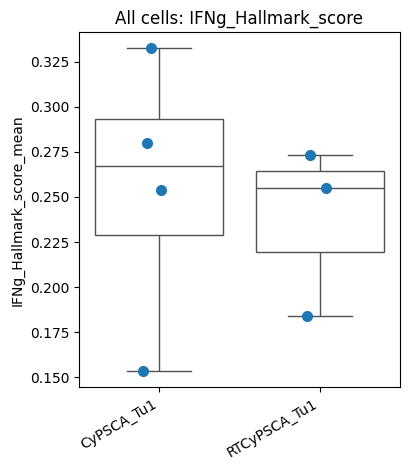

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/all_cells_IFNg_Hallmark_score_mean.png


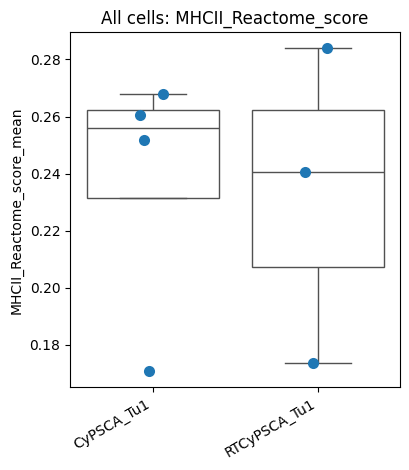

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/all_cells_MHCII_Reactome_score_mean.png


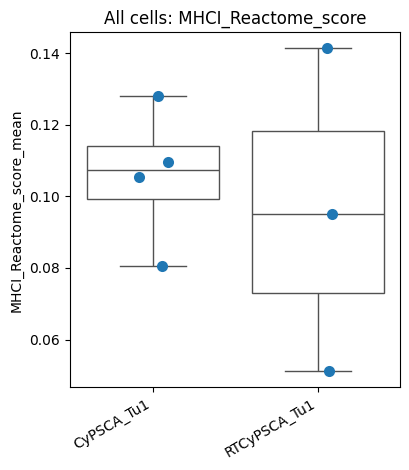

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/all_cells_MHCI_Reactome_score_mean.png


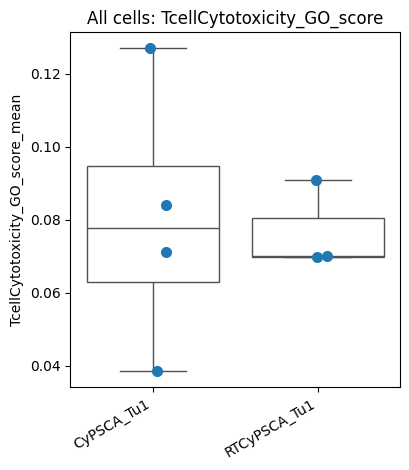

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/all_cells_TcellCytotoxicity_GO_score_mean.png


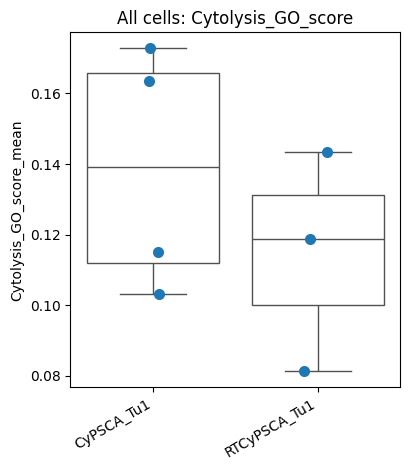

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/all_cells_Cytolysis_GO_score_mean.png


In [25]:
for score_col in primary_plot_scores:
    plot_tissue_metric(
        tissue_summary_all,
        score_col,
        metric_suffix="_mean",
        title_prefix="All cells: ",
        save_prefix="all_cells"
    )

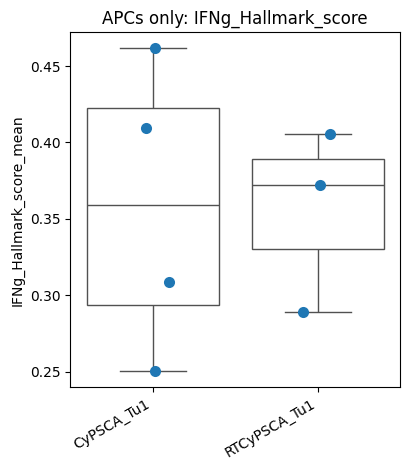

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/apc_only_IFNg_Hallmark_score_mean.png


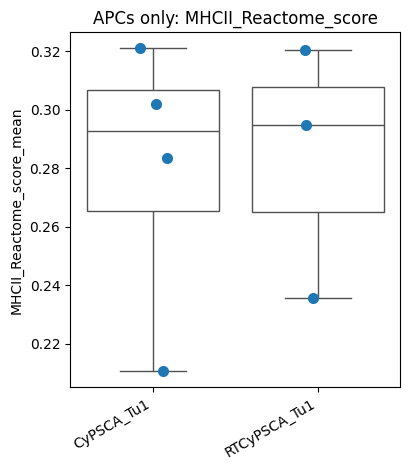

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/apc_only_MHCII_Reactome_score_mean.png


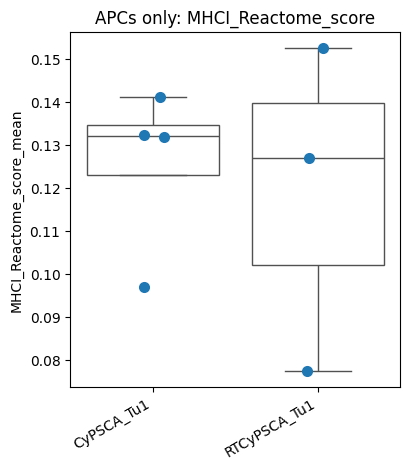

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/apc_only_MHCI_Reactome_score_mean.png


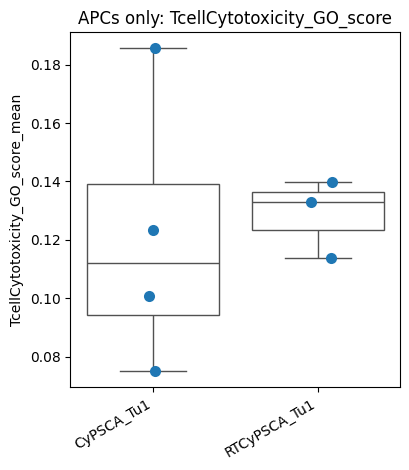

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/apc_only_TcellCytotoxicity_GO_score_mean.png


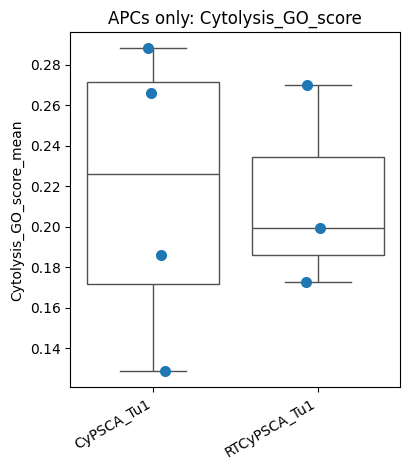

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/apc_only_Cytolysis_GO_score_mean.png


In [26]:
for score_col in primary_plot_scores:
    plot_tissue_metric(
        tissue_summary_apc,
        score_col,
        metric_suffix="_mean",
        title_prefix="APCs only: ",
        save_prefix="apc_only"
    )

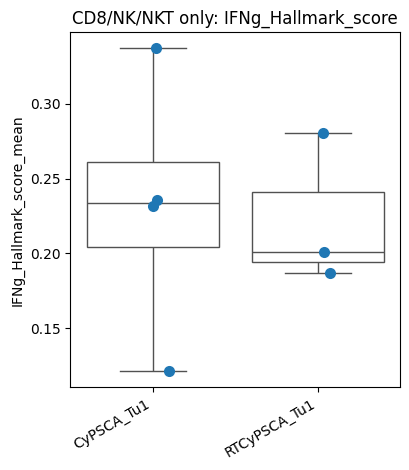

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/cytotoxic_only_IFNg_Hallmark_score_mean.png


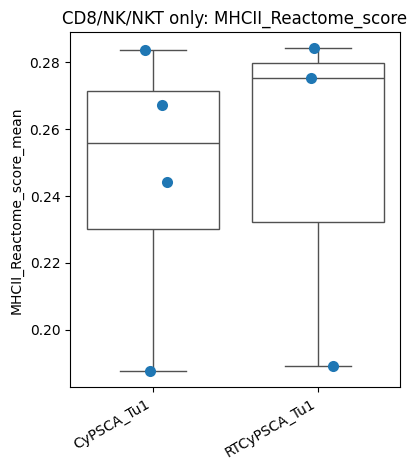

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/cytotoxic_only_MHCII_Reactome_score_mean.png


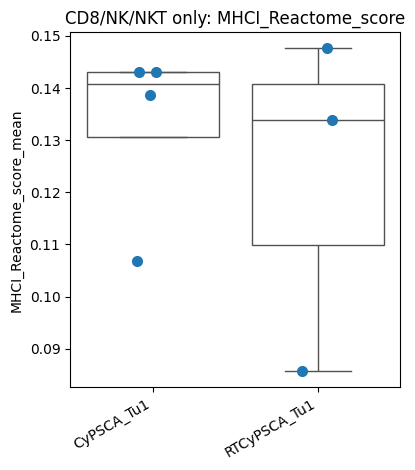

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/cytotoxic_only_MHCI_Reactome_score_mean.png


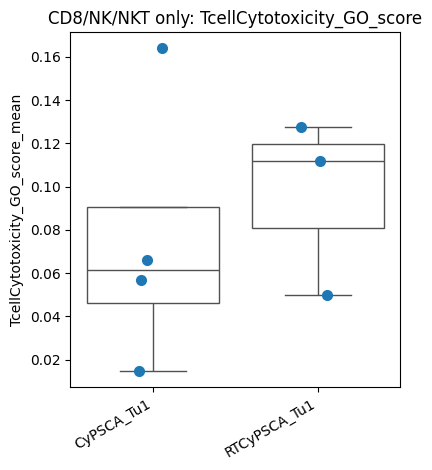

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/cytotoxic_only_TcellCytotoxicity_GO_score_mean.png


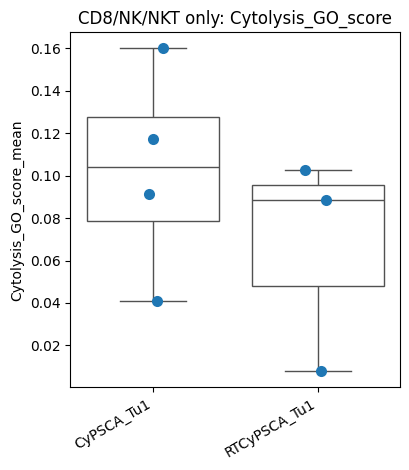

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/cytotoxic_only_Cytolysis_GO_score_mean.png


In [27]:
for score_col in primary_plot_scores:
    plot_tissue_metric(
        tissue_summary_cytotoxic,
        score_col,
        metric_suffix="_mean",
        title_prefix="CD8/NK/NKT only: ",
        save_prefix="cytotoxic_only"
    )

# Compar all tissues including tumore 2

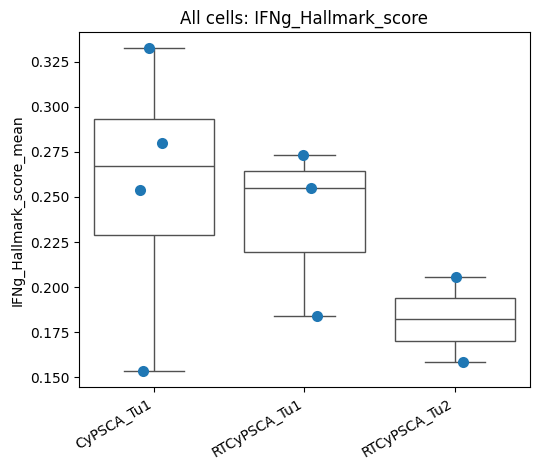

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/all_cells_CyPSCA_Tu1_RTCyPSCA_Tu1_Tu2_IFNg_Hallmark_score_mean.png


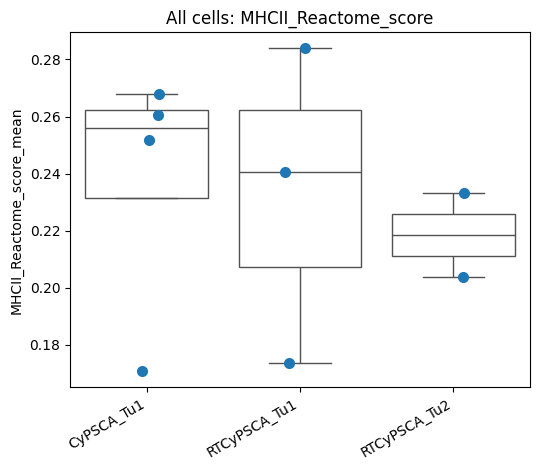

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/all_cells_CyPSCA_Tu1_RTCyPSCA_Tu1_Tu2_MHCII_Reactome_score_mean.png


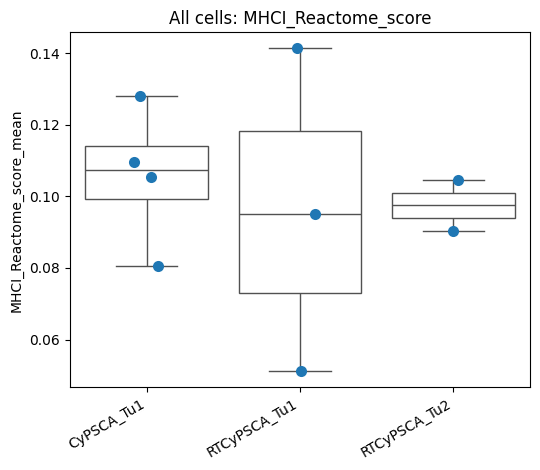

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/all_cells_CyPSCA_Tu1_RTCyPSCA_Tu1_Tu2_MHCI_Reactome_score_mean.png


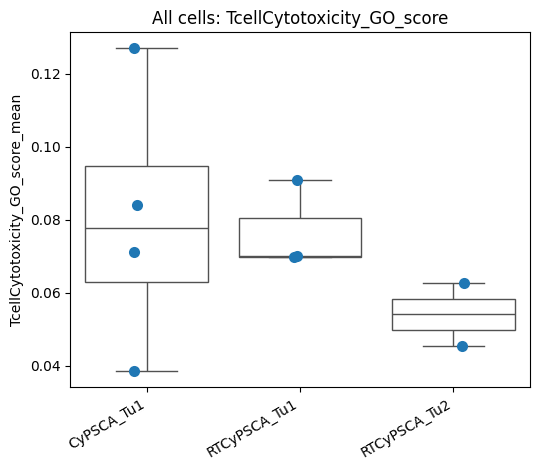

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/all_cells_CyPSCA_Tu1_RTCyPSCA_Tu1_Tu2_TcellCytotoxicity_GO_score_mean.png


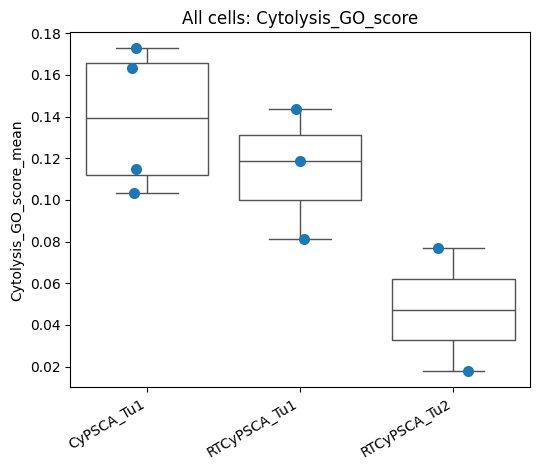

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/all_cells_CyPSCA_Tu1_RTCyPSCA_Tu1_Tu2_Cytolysis_GO_score_mean.png


In [28]:
plot_treatments = [
    "CyPSCA_Tu1",
    "RTCyPSCA_Tu1",
    "RTCyPSCA_Tu2",
]

for score_col in primary_plot_scores:
    metric = f"{score_col}_mean"

    plot_df = tissue_summary_all.loc[
        tissue_summary_all["treatment"].isin(plot_treatments)
    ].copy()

    plt.figure(figsize=(5.5, 4.8))

    sns.stripplot(
        data=plot_df,
        x="treatment",
        y=metric,
        size=8,
        jitter=True
    )

    sns.boxplot(
        data=plot_df,
        x="treatment",
        y=metric,
        showfliers=False,
        showcaps=True,
        boxprops={"facecolor": "none"},
        whiskerprops={"linewidth": 1}
    )

    plt.xticks(rotation=30, ha="right")
    plt.xlabel("")
    plt.ylabel(metric)
    plt.title(f"All cells: {score_col}")
    plt.tight_layout()

    outfile = outdir / f"all_cells_CyPSCA_Tu1_RTCyPSCA_Tu1_Tu2_{metric}.png"
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {outfile}")

# Morans I

In [29]:
moran_tissues = [
    "CyPSCA_1_1",
    "CyPSCA_1_2",
    "CyPSCA_1_3",
    "CyPSCA_1_4",
    "RTCyPSCA_1_2",
    "RTCyPSCA_1_3",
    "RTCyPSCA_1_4",
    "RTCyPSCA_2_3",
    "RTCyPSCA_2_4",
]

moran_score_cols = primary_plot_scores

print("Moran tissues:")
print(moran_tissues)

print("\nMoran score columns:")
print(moran_score_cols)

Moran tissues:
['CyPSCA_1_1', 'CyPSCA_1_2', 'CyPSCA_1_3', 'CyPSCA_1_4', 'RTCyPSCA_1_2', 'RTCyPSCA_1_3', 'RTCyPSCA_1_4', 'RTCyPSCA_2_3', 'RTCyPSCA_2_4']

Moran score columns:
['IFNg_Hallmark_score', 'MHCII_Reactome_score', 'MHCI_Reactome_score', 'TcellCytotoxicity_GO_score', 'Cytolysis_GO_score']


In [30]:
moran_results = []

for tissue in moran_tissues:
    print(f"\nRunning Moran's I for tissue: {tissue}")

    ad_t = adata[adata.obs["tissue"].astype(str).eq(tissue)].copy()

    print(f"  n cells: {ad_t.n_obs:,}")

    if ad_t.n_obs < 100:
        print("  Skipping because tissue has fewer than 100 cells.")
        continue

    sq.gr.spatial_neighbors(
        ad_t,
        spatial_key="spatial",
        coord_type="generic",
        n_neighs=6
    )

    sq.gr.spatial_autocorr(
        ad_t,
        mode="moran",
        genes=moran_score_cols,
        attr="obs",
        n_perms=999,
        n_jobs=8
    )

    res = ad_t.uns["moranI"].copy()
    res = res.reset_index().rename(columns={"index": "score_col"})

    meta_cols = ["tissue", "condition", "tumor_loc", "replicate_num", "treatment"]
    for col in meta_cols:
        res[col] = ad_t.obs[col].astype(str).iloc[0]

    res["n_cells"] = ad_t.n_obs
    res["n_neighs"] = 6
    res["n_perms"] = 999

    moran_results.append(res)

moran_df = pd.concat(moran_results, ignore_index=True)
display(moran_df)

moran_df.to_csv(
    outdir / "moranI_pathway_scores_per_tissue.csv",
    index=False
)


Running Moran's I for tissue: CyPSCA_1_1
  n cells: 108,895


  0%|          | 0/999 [00:00<?, ?/s]

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration opt


Running Moran's I for tissue: CyPSCA_1_2
  n cells: 55,540


  0%|          | 0/999 [00:00<?, ?/s]

...


Running Moran's I for tissue: RTCyPSCA_2_3
  n cells: 112,486


  0%|          | 0/999 [00:00<?, ?/s]


Running Moran's I for tissue: RTCyPSCA_2_4
  n cells: 65,157


  0%|          | 0/999 [00:00<?, ?/s]

,score_col,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh,tissue,condition,tumor_loc,replicate_num,treatment,n_cells,n_neighs,n_perms
0,IFNg_Hallmark_score,0.579371,0.0,0.000003,0.0,0.001,0.000005,0.0,0.0,0.001,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,108895,6,999
1,Cytolysis_GO_score,0.303600,0.0,0.000003,0.0,0.001,0.000004,0.0,0.0,0.001,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,108895,6,999
2,TcellCytotoxicity_GO_score,0.290670,0.0,0.000003,0.0,0.001,0.000003,0.0,0.0,0.001,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,108895,6,999
3,MHCI_Reactome_score,0.181910,0.0,0.000003,0.0,0.001,0.000003,0.0,0.0,0.001,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,108895,6,999
4,MHCII_Reactome_score,0.179341,0.0,0.000003,0.0,0.001,0.000003,0.0,0.0,0.001,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,108895,6,999
5,IFNg_Hallmark_score,0.704741,0.0,0.000006,0.0,0.001,0.000013,0.0,0.0,0.001,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,55540,6,999
6,TcellCytotoxicity_GO_score,0.492159,0.0,0.000006,0.0,0.001,0.000009,0.0,0.0,0.001,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,55540,6,999
7,Cytolysis_GO_score,0.450695,0.0,0.000006,0.0,0.001,0.000009,0.0,0.0,0.001,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,55540,6,999
8,MHCII_Reactome_score,0.232344,0.0,0.000006,0.0,0.001,0.000006,0.0,0.0,0.001,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,55540,6,999
9,MHCI_Reactome_score,0.217139,0.0,0.000006,0.0,0.001,0.000005,0.0,0.0,0.001,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,55540,6,999


In [31]:
moran_metric_cols = ["I"]

moran_comparison_rows = []

for score_col in moran_score_cols:
    sub = moran_df.loc[
        moran_df["score_col"].eq(score_col)
        & moran_df["treatment"].isin(["CyPSCA_Tu1", "RTCyPSCA_Tu1"])
    ].copy()

    x = sub.loc[sub["treatment"].eq("CyPSCA_Tu1"), "I"].dropna()
    y = sub.loc[sub["treatment"].eq("RTCyPSCA_Tu1"), "I"].dropna()

    if len(x) >= 2 and len(y) >= 2:
        stat, p = mannwhitneyu(x, y, alternative="two-sided", method="auto")
        delta = cliffs_delta(y, x)
    else:
        stat, p, delta = np.nan, np.nan, np.nan

    moran_comparison_rows.append({
        "score_col": score_col,
        "n_CyPSCA_Tu1": len(x),
        "n_RTCyPSCA_Tu1": len(y),
        "mean_I_CyPSCA_Tu1": x.mean(),
        "mean_I_RTCyPSCA_Tu1": y.mean(),
        "difference_mean_I_RTCyPSCA_minus_CyPSCA": y.mean() - x.mean(),
        "mannwhitney_p": p,
        "cliffs_delta_RTCyPSCA_vs_CyPSCA": delta,
    })

moran_comparison_df = pd.DataFrame(moran_comparison_rows)

moran_comparison_df["mannwhitney_fdr"] = multipletests(
    moran_comparison_df["mannwhitney_p"].fillna(1.0),
    method="fdr_bh"
)[1]

display(moran_comparison_df)

moran_comparison_df.to_csv(
    outdir / "CyPSCA_Tu1_vs_RTCyPSCA_Tu1_moranI_comparison.csv",
    index=False
)

,score_col,n_CyPSCA_Tu1,n_RTCyPSCA_Tu1,mean_I_CyPSCA_Tu1,mean_I_RTCyPSCA_Tu1,difference_mean_I_RTCyPSCA_minus_CyPSCA,mannwhitney_p,cliffs_delta_RTCyPSCA_vs_CyPSCA,mannwhitney_fdr
0,IFNg_Hallmark_score,4,3,0.641715,0.641885,0.000170,0.628571,0.333333,0.857143
1,MHCII_Reactome_score,4,3,0.274038,0.304880,0.030842,0.628571,0.333333,0.857143
2,MHCI_Reactome_score,4,3,0.321019,0.387115,0.066097,0.628571,0.333333,0.857143
3,TcellCytotoxicity_GO_score,4,3,0.374795,0.427153,0.052358,0.857143,0.166667,0.857143
4,Cytolysis_GO_score,4,3,0.362487,0.362903,0.000415,0.857143,0.166667,0.857143


In [32]:
moran_metric_cols = ["I"]

moran_comparison_rows = []

for score_col in moran_score_cols:
    sub = moran_df.loc[
        moran_df["score_col"].eq(score_col)
        & moran_df["treatment"].isin(["CyPSCA_Tu1", "RTCyPSCA_Tu1"])
    ].copy()

    x = sub.loc[sub["treatment"].eq("CyPSCA_Tu1"), "I"].dropna()
    y = sub.loc[sub["treatment"].eq("RTCyPSCA_Tu1"), "I"].dropna()

    if len(x) >= 2 and len(y) >= 2:
        stat, p = mannwhitneyu(x, y, alternative="two-sided", method="auto")
        delta = cliffs_delta(y, x)
    else:
        stat, p, delta = np.nan, np.nan, np.nan

    moran_comparison_rows.append({
        "score_col": score_col,
        "n_CyPSCA_Tu1": len(x),
        "n_RTCyPSCA_Tu1": len(y),
        "mean_I_CyPSCA_Tu1": x.mean(),
        "mean_I_RTCyPSCA_Tu1": y.mean(),
        "difference_mean_I_RTCyPSCA_minus_CyPSCA": y.mean() - x.mean(),
        "mannwhitney_p": p,
        "cliffs_delta_RTCyPSCA_vs_CyPSCA": delta,
    })

moran_comparison_df = pd.DataFrame(moran_comparison_rows)

moran_comparison_df["mannwhitney_fdr"] = multipletests(
    moran_comparison_df["mannwhitney_p"].fillna(1.0),
    method="fdr_bh"
)[1]

display(moran_comparison_df)

moran_comparison_df.to_csv(
    outdir / "CyPSCA_Tu1_vs_RTCyPSCA_Tu1_moranI_comparison.csv",
    index=False
)

,score_col,n_CyPSCA_Tu1,n_RTCyPSCA_Tu1,mean_I_CyPSCA_Tu1,mean_I_RTCyPSCA_Tu1,difference_mean_I_RTCyPSCA_minus_CyPSCA,mannwhitney_p,cliffs_delta_RTCyPSCA_vs_CyPSCA,mannwhitney_fdr
0,IFNg_Hallmark_score,4,3,0.641715,0.641885,0.000170,0.628571,0.333333,0.857143
1,MHCII_Reactome_score,4,3,0.274038,0.304880,0.030842,0.628571,0.333333,0.857143
2,MHCI_Reactome_score,4,3,0.321019,0.387115,0.066097,0.628571,0.333333,0.857143
3,TcellCytotoxicity_GO_score,4,3,0.374795,0.427153,0.052358,0.857143,0.166667,0.857143
4,Cytolysis_GO_score,4,3,0.362487,0.362903,0.000415,0.857143,0.166667,0.857143


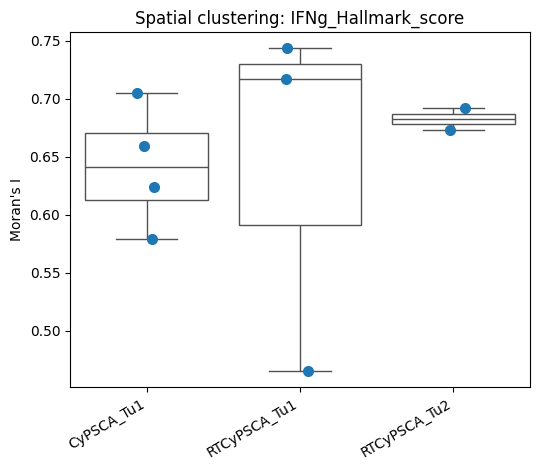

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/moranI_IFNg_Hallmark_score_CyPSCA_RTCyPSCA_Tu1_Tu2.png


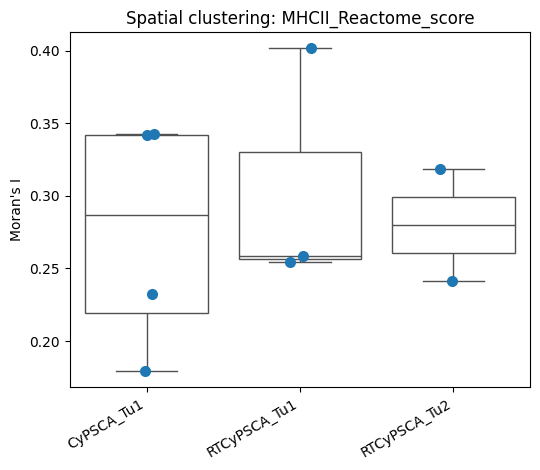

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/moranI_MHCII_Reactome_score_CyPSCA_RTCyPSCA_Tu1_Tu2.png


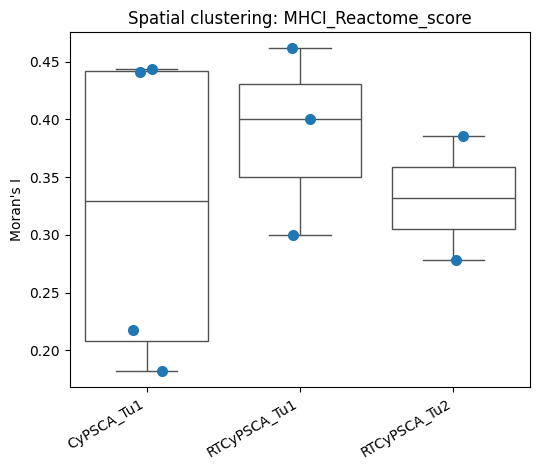

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/moranI_MHCI_Reactome_score_CyPSCA_RTCyPSCA_Tu1_Tu2.png


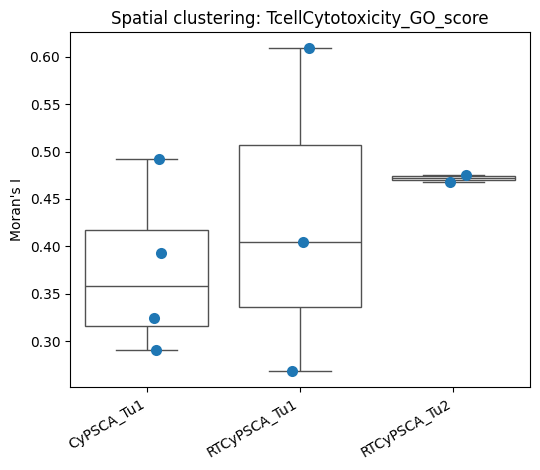

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/moranI_TcellCytotoxicity_GO_score_CyPSCA_RTCyPSCA_Tu1_Tu2.png


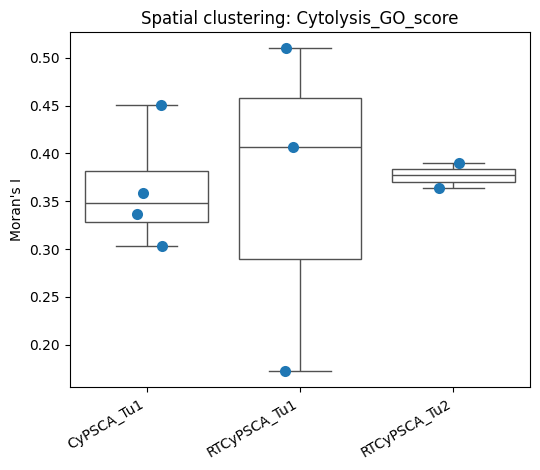

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/moranI_Cytolysis_GO_score_CyPSCA_RTCyPSCA_Tu1_Tu2.png


In [33]:
plot_df = moran_df.loc[
    moran_df["treatment"].isin(["CyPSCA_Tu1", "RTCyPSCA_Tu1", "RTCyPSCA_Tu2"])
].copy()

for score_col in moran_score_cols:
    sub = plot_df.loc[plot_df["score_col"].eq(score_col)].copy()

    plt.figure(figsize=(5.5, 4.8))

    sns.stripplot(
        data=sub,
        x="treatment",
        y="I",
        size=8,
        jitter=True
    )

    sns.boxplot(
        data=sub,
        x="treatment",
        y="I",
        showfliers=False,
        showcaps=True,
        boxprops={"facecolor": "none"},
        whiskerprops={"linewidth": 1}
    )

    plt.xticks(rotation=30, ha="right")
    plt.xlabel("")
    plt.ylabel("Moran's I")
    plt.title(f"Spatial clustering: {score_col}")
    plt.tight_layout()

    outfile = outdir / f"moranI_{score_col}_CyPSCA_RTCyPSCA_Tu1_Tu2.png"
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {outfile}")

In [34]:
compact_all = tissue_summary_all.copy()
compact_apc = tissue_summary_apc.copy()
compact_cyto = tissue_summary_cytotoxic.copy()

compact_all["cell_universe"] = "all_cells"
compact_apc["cell_universe"] = "apc_only"
compact_cyto["cell_universe"] = "cytotoxic_lymphocytes_only"

common_cols = [
    "tissue",
    "condition",
    "tumor_loc",
    "replicate_num",
    "treatment",
    "cell_universe",
]

compact_summary = pd.concat(
    [
        compact_all,
        compact_apc,
        compact_cyto,
    ],
    ignore_index=True,
    sort=False
)

compact_summary.to_csv(
    outdir / "combined_tissue_level_pathway_summary_all_universes.csv",
    index=False
)

print("Saved compact summary:")
print(outdir / "combined_tissue_level_pathway_summary_all_universes.csv")

Saved compact summary:
/coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm/combined_tissue_level_pathway_summary_all_universes.csv


# Cell Composition

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

celltype_col = "c2l_permissive"

composition_df = (
    adata.obs
    .groupby(["tissue", "condition", "tumor_loc", "replicate_num", "treatment", celltype_col], observed=True)
    .size()
    .reset_index(name="n_cells_type")
)

total_per_tissue = (
    adata.obs
    .groupby(["tissue", "condition", "tumor_loc", "replicate_num", "treatment"], observed=True)
    .size()
    .reset_index(name="n_cells_total")
)

composition_df = composition_df.merge(
    total_per_tissue,
    on=["tissue", "condition", "tumor_loc", "replicate_num", "treatment"],
    how="left"
)

composition_df["fraction"] = composition_df["n_cells_type"] / composition_df["n_cells_total"]

display(composition_df.head())

,tissue,condition,tumor_loc,replicate_num,treatment,c2l_permissive,n_cells_type,n_cells_total,fraction
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,B,2251,108895,0.020671
1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,CD4_T,1198,108895,0.011001
2,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,CD8_T,5347,108895,0.049102
3,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,Cancer_cell,9022,108895,0.082850
4,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,Classical_Mono,4474,108895,0.041085


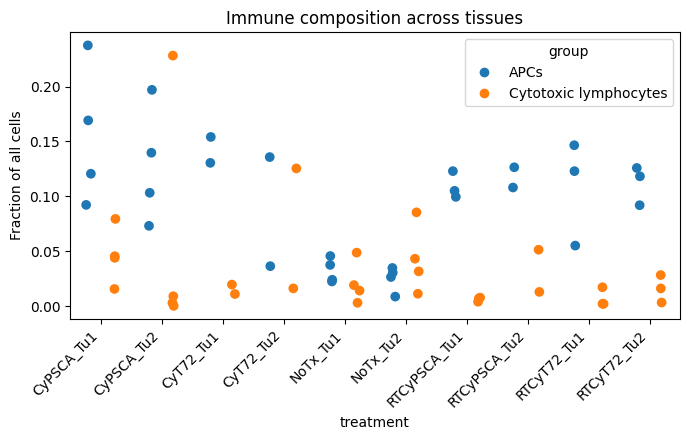

In [36]:
cytotoxic_types = ["CD8_T", "NK", "NKT"]
apc_types = [
    "M1_like_Mac", "M2_like_Mac", "Intermediate_Mac",
    "Classical_Mono", "Nonclassical_Mono", "cDC", "pDC", "B"
]

composition_grouped = (
    composition_df
    .assign(
        group=lambda x: np.select(
            [
                x[celltype_col].isin(cytotoxic_types),
                x[celltype_col].isin(apc_types),
            ],
            [
                "Cytotoxic lymphocytes",
                "APCs",
            ],
            default="Other"
        )
    )
    .groupby(["tissue", "condition", "tumor_loc", "replicate_num", "treatment", "group"], observed=True)
    .agg(fraction=("fraction", "sum"), n_cells_type=("n_cells_type", "sum"))
    .reset_index()
)

plot_groups = ["Cytotoxic lymphocytes", "APCs"]

plt.figure(figsize=(7, 4.5))
sns.stripplot(
    data=composition_grouped.query("group in @plot_groups"),
    x="treatment",
    y="fraction",
    hue="group",
    dodge=True,
    size=7
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Fraction of all cells")
plt.title("Immune composition across tissues")
plt.tight_layout()
plt.show()

In [37]:
score_cols = [
    "IFNg_Hallmark_score",
    "MHCII_Reactome_score",
    "MHCI_Reactome_score",
    "AntigenPresentation_GO_score",
    "TcellCytotoxicity_GO_score",
    "Cytolysis_GO_score",
    "GranzymeDeath_GO_score",
]

score_cols = [c for c in score_cols if c in adata.obs.columns]

celltype_score_summary = (
    adata.obs
    .loc[
        adata.obs["treatment"].isin(["CyPSCA_Tu1", "RTCyPSCA_Tu1", "RTCyPSCA_Tu2"])
    ]
    .groupby(["tissue", "treatment", celltype_col], observed=True)
    .agg(
        n_cells=(celltype_col, "size"),
        **{f"{c}_mean": (c, "mean") for c in score_cols}
    )
    .reset_index()
)

display(celltype_score_summary.head())

,tissue,treatment,c2l_permissive,n_cells,IFNg_Hallmark_score_mean,MHCII_Reactome_score_mean,MHCI_Reactome_score_mean,AntigenPresentation_GO_score_mean,TcellCytotoxicity_GO_score_mean,Cytolysis_GO_score_mean,GranzymeDeath_GO_score_mean
0,CyPSCA_1_1,CyPSCA_Tu1,B,2251,0.095814,0.167270,0.097440,0.085889,0.001311,0.010852,-0.038128
1,CyPSCA_1_1,CyPSCA_Tu1,CD4_T,1198,0.068919,0.157481,0.098861,0.067815,-0.007478,-0.026660,-0.051670
2,CyPSCA_1_1,CyPSCA_Tu1,CD8_T,5347,0.133519,0.195275,0.110229,0.110345,0.014505,0.058612,-0.013780
3,CyPSCA_1_1,CyPSCA_Tu1,Cancer_cell,9022,0.079811,0.176366,0.103203,0.074544,-0.005338,-0.025123,-0.046881
4,CyPSCA_1_1,CyPSCA_Tu1,Classical_Mono,4474,0.341807,0.215366,0.101904,0.247843,0.104159,0.286800,0.164354


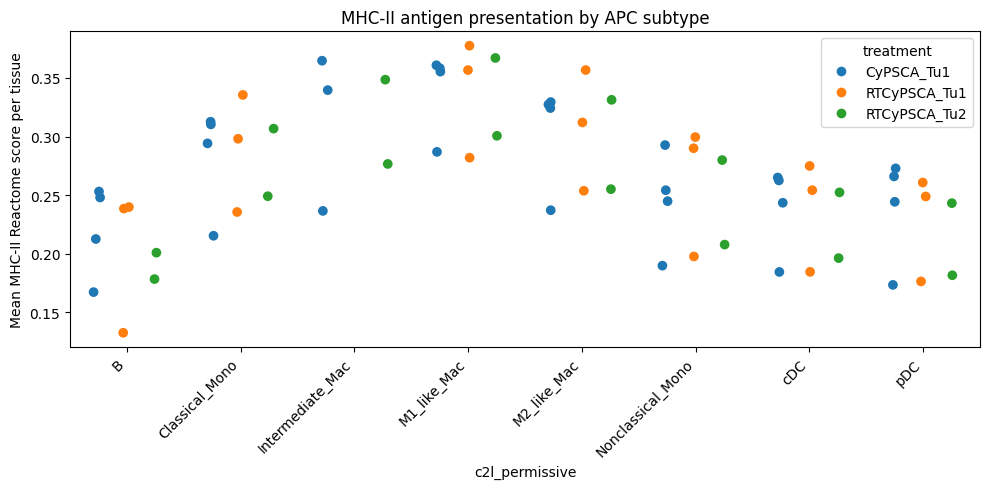

In [38]:
apc_score_plot = celltype_score_summary.query(
    f"{celltype_col} in @apc_types and n_cells >= 25"
).copy()

plt.figure(figsize=(10, 5))
sns.stripplot(
    data=apc_score_plot,
    x=celltype_col,
    y="MHCII_Reactome_score_mean",
    hue="treatment",
    dodge=True,
    size=7
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean MHC-II Reactome score per tissue")
plt.title("MHC-II antigen presentation by APC subtype")
plt.tight_layout()
plt.show()

# Marker Genes

In [39]:
marker_genes = [
    # IFN response
    "Ifng", "Stat1", "Irf1", "Cxcl9", "Cxcl10",

    # MHC-II / APC
    "Cd74", "H2-Aa", "H2-Ab1", "H2-Eb1", "Ciita", "Ctss",

    # MHC-I
    "B2m", "H2-K1", "H2-D1", "Tap1", "Tap2",

    # Cytotoxicity
    "Gzmb", "Gzma", "Prf1", "Nkg7", "Ccl5",
]

marker_genes = [g for g in marker_genes if g in adata.var_names]
print(marker_genes)

['Ifng', 'Stat1', 'Irf1', 'Cxcl9', 'Cxcl10', 'Cd74', 'H2-Aa', 'H2-Ab1', 'H2-Eb1', 'Ciita', 'Ctss', 'B2m', 'H2-K1', 'H2-D1', 'Tap1', 'Tap2', 'Gzmb', 'Gzma', 'Prf1', 'Nkg7', 'Ccl5']


In [40]:
marker_summary = (
    adata[:, marker_genes]
    .to_df()
    .join(adata.obs[["tissue", "treatment", celltype_col]])
    .groupby(["tissue", "treatment", celltype_col], observed=True)
    .mean()
    .reset_index()
)

display(marker_summary.head())

,tissue,treatment,c2l_permissive,Ifng,Stat1,Irf1,Cxcl9,Cxcl10,Cd74,H2-Aa,...,B2m,H2-K1,H2-D1,Tap1,Tap2,Gzmb,Gzma,Prf1,Nkg7,Ccl5
0,CyPSCA_1_1,CyPSCA_Tu1,B,0.021051,1.184638,0.871842,0.507802,0.467455,1.356646,0.872759,...,1.052735,0.621792,0.211579,0.264685,0.165473,0.171576,0.018963,0.107565,0.024710,0.148763
1,CyPSCA_1_1,CyPSCA_Tu1,CD4_T,0.017460,1.063261,0.688529,0.365911,0.362543,1.051071,0.660683,...,0.922363,0.483952,0.174649,0.185740,0.143981,0.124664,0.012461,0.098333,0.021777,0.119054
2,CyPSCA_1_1,CyPSCA_Tu1,CD8_T,0.022940,1.555056,1.094599,0.706898,0.628683,1.629664,1.068480,...,1.232324,0.765879,0.265698,0.295218,0.211360,0.215374,0.028352,0.126821,0.042388,0.230135
3,CyPSCA_1_1,CyPSCA_Tu1,Cancer_cell,0.011317,1.066770,0.712633,0.341038,0.372870,1.142665,0.691627,...,1.003956,0.531528,0.192101,0.170839,0.117597,0.154477,0.015625,0.097824,0.023495,0.117394
4,CyPSCA_1_1,CyPSCA_Tu1,Classical_Mono,0.075524,2.358485,1.415798,1.996529,2.115303,2.884100,2.053416,...,1.918407,1.423339,0.488322,0.617252,0.474116,0.458853,0.094514,0.242683,0.094838,0.702343


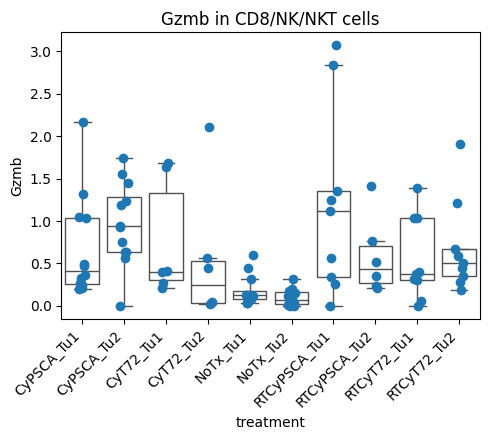

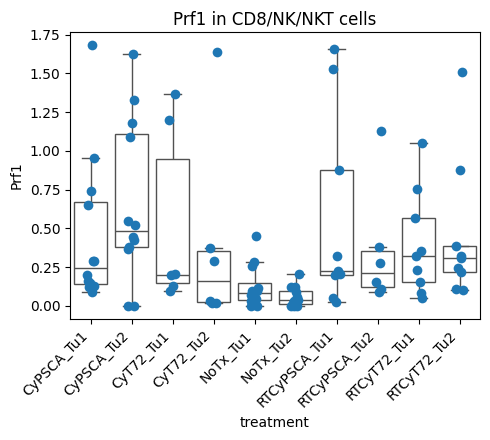

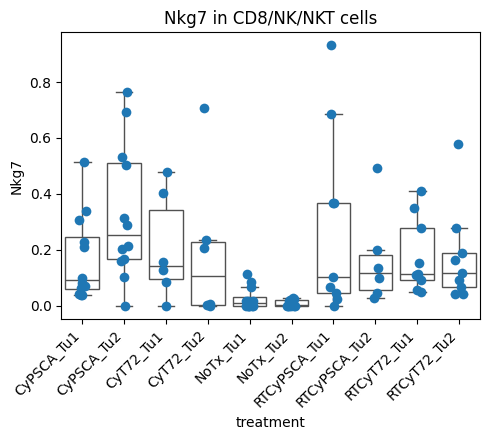

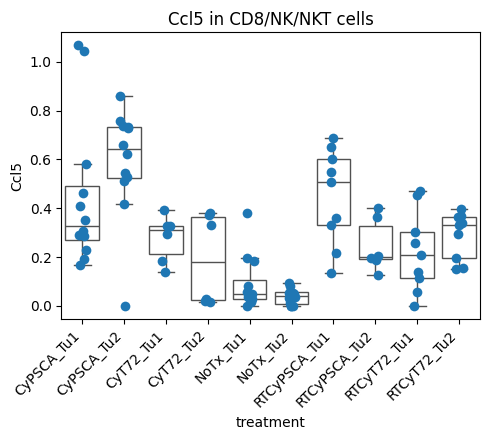

In [41]:
cyto_marker_summary = marker_summary.query(
    f"{celltype_col} in @cytotoxic_types"
).copy()

for gene in ["Gzmb", "Prf1", "Nkg7", "Ccl5"]:
    if gene not in cyto_marker_summary.columns:
        continue

    plt.figure(figsize=(5, 4.5))
    sns.stripplot(
        data=cyto_marker_summary,
        x="treatment",
        y=gene,
        size=7,
        jitter=True
    )
    sns.boxplot(
        data=cyto_marker_summary,
        x="treatment",
        y=gene,
        showfliers=False,
        boxprops={"facecolor": "none"}
    )
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{gene} in CD8/NK/NKT cells")
    plt.tight_layout()
    plt.show()

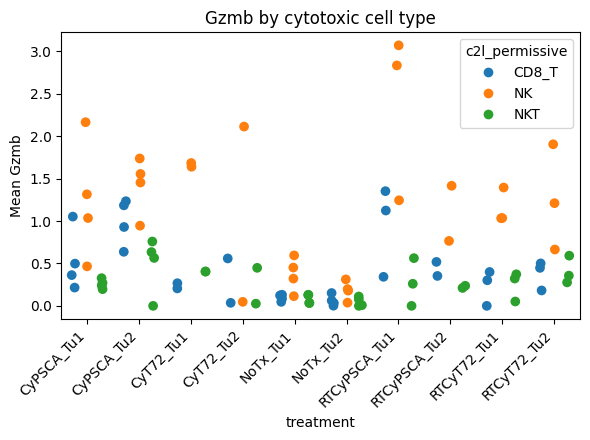

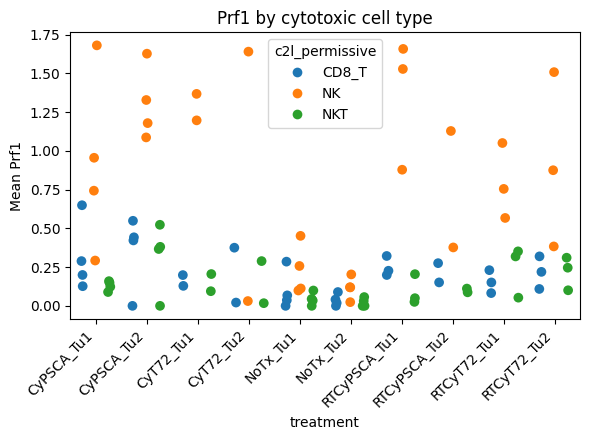

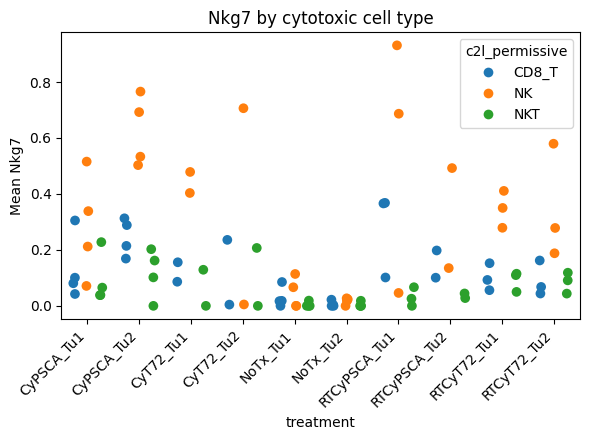

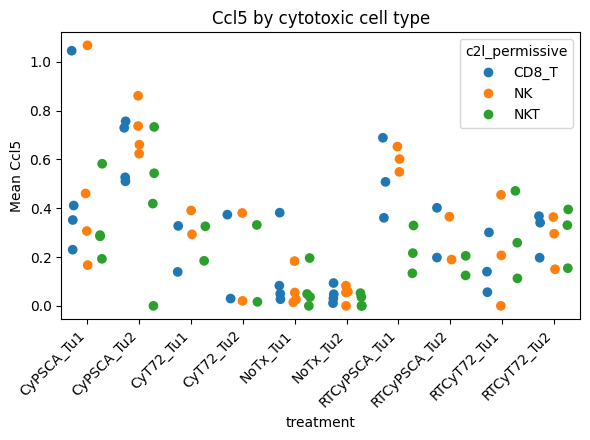

In [42]:
for gene in ["Gzmb", "Prf1", "Nkg7", "Ccl5"]:
    if gene not in cyto_marker_summary.columns:
        continue

    plt.figure(figsize=(6, 4.5))
    sns.stripplot(
        data=cyto_marker_summary,
        x="treatment",
        y=gene,
        hue=celltype_col,
        dodge=True,
        size=7,
        jitter=True
    )
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(f"Mean {gene}")
    plt.title(f"{gene} by cytotoxic cell type")
    plt.tight_layout()
    plt.show()

# NK Cells

In [11]:
celltype_col = "c2l_permissive"

lymphocyte_types = [
    "CD8_T",
    "CD4_T",
    "Treg",
    "NK",
    "NKT",
    "B",
]

cytotoxic_lymphocyte_types = [
    "CD8_T",
    "NK",
    "NKT",
]

nk_types = ["NK"]

focus_treatments = [
    "CyPSCA_Tu1",
    "RTCyPSCA_Tu1",
    "RTCyPSCA_Tu2",
    "CyT72_Tu1",
    "RTCyT72_Tu1",
    "NoTx_Tu1",
]

adata.obs["is_lymphocyte"] = adata.obs[celltype_col].astype(str).isin(lymphocyte_types)
adata.obs["is_cytotoxic_lymphocyte"] = adata.obs[celltype_col].astype(str).isin(cytotoxic_lymphocyte_types)
adata.obs["is_nk"] = adata.obs[celltype_col].astype(str).eq("NK")

print("Lymphocyte labels included:")
print(lymphocyte_types)

print("\nCounts:")
print(adata.obs[["is_lymphocyte", "is_cytotoxic_lymphocyte", "is_nk"]].sum())

Lymphocyte labels included:
['CD8_T', 'CD4_T', 'Treg', 'NK', 'NKT', 'B']

Counts:
is_lymphocyte              130406
is_cytotoxic_lymphocyte     75725
is_nk                       22914
dtype: int64


In [12]:
marker_genes = [
    "Gzmb", "Gzma", "Prf1", "Nkg7", "Ccl5", "Ifng",
    "Klrd1", "Klrk1", "Ncr1", "Fasl"
]

marker_genes = [g for g in marker_genes if g in adata.var_names]

print("Marker genes found:")
print(marker_genes)

marker_expr = adata[:, marker_genes].to_df()

for gene in marker_genes:
    adata.obs[f"{gene}_expr"] = marker_expr[gene].values

Marker genes found:
['Gzmb', 'Gzma', 'Prf1', 'Nkg7', 'Ccl5', 'Ifng', 'Klrd1', 'Klrk1', 'Ncr1', 'Fasl']


In [13]:
nk_mask_global = adata.obs["is_nk"]

for gene in ["Gzmb", "Prf1", "Nkg7", "Ccl5"]:
    expr_col = f"{gene}_expr"
    if expr_col not in adata.obs.columns:
        continue

    q75 = adata.obs.loc[nk_mask_global, expr_col].quantile(0.75)
    q90 = adata.obs.loc[nk_mask_global, expr_col].quantile(0.90)

    adata.obs[f"NK_{gene}_high_q75"] = adata.obs["is_nk"] & (adata.obs[expr_col] >= q75)
    adata.obs[f"NK_{gene}_high_q90"] = adata.obs["is_nk"] & (adata.obs[expr_col] >= q90)

    print(f"{gene}")
    print(f"  NK q75 threshold: {q75:.4f}")
    print(f"  NK q90 threshold: {q90:.4f}")

Gzmb
  NK q75 threshold: 1.7379
  NK q90 threshold: 2.9598
Prf1
  NK q75 threshold: 0.0000
  NK q90 threshold: 2.5348
Nkg7
  NK q75 threshold: 0.0000
  NK q90 threshold: 1.0930
Ccl5
  NK q75 threshold: 0.0000
  NK q90 threshold: 1.2408


In [14]:
nk_composition_summary = (
    adata.obs
    .loc[adata.obs["treatment"].isin(focus_treatments)]
    .groupby(["tissue", "condition", "tumor_loc", "replicate_num", "treatment"], observed=True)
    .agg(
        n_total_cells=("tissue", "size"),
        n_lymphocytes=("is_lymphocyte", "sum"),
        n_cytotoxic_lymphocytes=("is_cytotoxic_lymphocyte", "sum"),
        n_nk=("is_nk", "sum"),
    )
    .reset_index()
)

nk_composition_summary["frac_nk_of_lymphocytes"] = (
    nk_composition_summary["n_nk"] / nk_composition_summary["n_lymphocytes"]
)

nk_composition_summary["frac_cytotoxic_of_lymphocytes"] = (
    nk_composition_summary["n_cytotoxic_lymphocytes"] / nk_composition_summary["n_lymphocytes"]
)

display(nk_composition_summary)

,tissue,condition,tumor_loc,replicate_num,treatment,n_total_cells,n_lymphocytes,n_cytotoxic_lymphocytes,n_nk,frac_nk_of_lymphocytes,frac_cytotoxic_of_lymphocytes
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,108895,12497,8664,2400,0.192046,0.693286
1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,55540,4704,2452,722,0.153486,0.521259
2,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1,33085,927,524,247,0.266451,0.565264
3,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1,27025,2328,1234,252,0.108247,0.530069
4,CyT72_1_2,CyT72,1,2,CyT72_Tu1,34108,731,383,154,0.210670,0.523940
5,CyT72_1_4,CyT72,1,4,CyT72_Tu1,49785,1968,987,340,0.172764,0.501524
6,NoTx_1_1,NoTx,1,1,NoTx_Tu1,44929,1114,147,19,0.017056,0.131957
7,NoTx_1_2,NoTx,1,2,NoTx_Tu1,23792,1407,341,116,0.082445,0.242360
8,NoTx_1_3,NoTx,1,3,NoTx_Tu1,59018,2725,1141,181,0.066422,0.418716
9,NoTx_1_4,NoTx,1,4,NoTx_Tu1,34688,2608,1696,342,0.131135,0.650307


In [15]:
nk_activation_summary = (
    adata.obs
    .loc[
        adata.obs["treatment"].isin(focus_treatments)
        & adata.obs["is_nk"]
    ]
    .groupby(["tissue", "condition", "tumor_loc", "replicate_num", "treatment"], observed=True)
    .agg(
        n_nk=("is_nk", "size"),
        mean_Gzmb=("Gzmb_expr", "mean"),
        median_Gzmb=("Gzmb_expr", "median"),
        mean_Prf1=("Prf1_expr", "mean") if "Prf1_expr" in adata.obs.columns else ("is_nk", "size"),
        mean_Nkg7=("Nkg7_expr", "mean") if "Nkg7_expr" in adata.obs.columns else ("is_nk", "size"),
        mean_Ccl5=("Ccl5_expr", "mean") if "Ccl5_expr" in adata.obs.columns else ("is_nk", "size"),
        frac_NK_Gzmb_high_q75=("NK_Gzmb_high_q75", "mean"),
        frac_NK_Gzmb_high_q90=("NK_Gzmb_high_q90", "mean"),
    )
    .reset_index()
)

display(nk_activation_summary)

,tissue,condition,tumor_loc,replicate_num,treatment,n_nk,mean_Gzmb,median_Gzmb,mean_Prf1,mean_Nkg7,mean_Ccl5,frac_NK_Gzmb_high_q75,frac_NK_Gzmb_high_q90
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,2400,0.465761,0.000000,0.292344,0.071220,0.166972,0.167500,0.051667
1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,722,1.315295,0.000000,0.955207,0.338611,0.460537,0.441828,0.191136
2,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1,247,2.165560,2.456248,1.680344,0.515659,1.067305,0.716599,0.364372
3,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1,252,1.035405,0.000000,0.742958,0.211992,0.306611,0.365079,0.095238
4,CyT72_1_2,CyT72,1,2,CyT72_Tu1,154,1.684386,0.000000,1.367346,0.403488,0.293088,0.487013,0.376623
5,CyT72_1_4,CyT72,1,4,CyT72_Tu1,340,1.640304,2.038627,1.196521,0.478673,0.390812,0.558824,0.235294
6,NoTx_1_1,NoTx,1,1,NoTx_Tu1,19,0.451599,0.000000,0.112265,0.000000,0.183367,0.157895,0.052632
7,NoTx_1_2,NoTx,1,2,NoTx_Tu1,116,0.114298,0.000000,0.098995,0.000000,0.014571,0.034483,0.008621
8,NoTx_1_3,NoTx,1,3,NoTx_Tu1,181,0.595022,0.000000,0.451499,0.113933,0.026197,0.198895,0.049724
9,NoTx_1_4,NoTx,1,4,NoTx_Tu1,342,0.321145,0.000000,0.257243,0.066467,0.054800,0.099415,0.040936


In [16]:
nk_high_lymphocyte_summary = (
    adata.obs
    .loc[adata.obs["treatment"].isin(focus_treatments)]
    .groupby(["tissue", "condition", "tumor_loc", "replicate_num", "treatment"], observed=True)
    .agg(
        n_lymphocytes=("is_lymphocyte", "sum"),
        n_nk=("is_nk", "sum"),
        n_NK_Gzmb_high_q75=("NK_Gzmb_high_q75", "sum"),
        n_NK_Gzmb_high_q90=("NK_Gzmb_high_q90", "sum"),
    )
    .reset_index()
)

nk_high_lymphocyte_summary["frac_NK_Gzmb_high_q75_of_lymphocytes"] = (
    nk_high_lymphocyte_summary["n_NK_Gzmb_high_q75"] /
    nk_high_lymphocyte_summary["n_lymphocytes"]
)

nk_high_lymphocyte_summary["frac_NK_Gzmb_high_q90_of_lymphocytes"] = (
    nk_high_lymphocyte_summary["n_NK_Gzmb_high_q90"] /
    nk_high_lymphocyte_summary["n_lymphocytes"]
)

display(nk_high_lymphocyte_summary)

,tissue,condition,tumor_loc,replicate_num,treatment,n_lymphocytes,n_nk,n_NK_Gzmb_high_q75,n_NK_Gzmb_high_q90,frac_NK_Gzmb_high_q75_of_lymphocytes,frac_NK_Gzmb_high_q90_of_lymphocytes
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,12497,2400,402,124,0.032168,0.009922
1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,4704,722,319,138,0.067815,0.029337
2,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1,927,247,177,90,0.190939,0.097087
3,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1,2328,252,92,24,0.039519,0.010309
4,CyT72_1_2,CyT72,1,2,CyT72_Tu1,731,154,75,58,0.102599,0.079343
5,CyT72_1_4,CyT72,1,4,CyT72_Tu1,1968,340,190,80,0.096545,0.040650
6,NoTx_1_1,NoTx,1,1,NoTx_Tu1,1114,19,3,1,0.002693,0.000898
7,NoTx_1_2,NoTx,1,2,NoTx_Tu1,1407,116,4,1,0.002843,0.000711
8,NoTx_1_3,NoTx,1,3,NoTx_Tu1,2725,181,36,9,0.013211,0.003303
9,NoTx_1_4,NoTx,1,4,NoTx_Tu1,2608,342,34,14,0.013037,0.005368


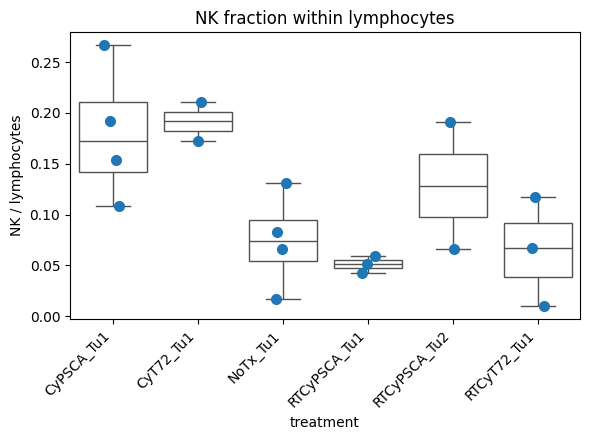

In [17]:
plot_df = nk_composition_summary.copy()

plt.figure(figsize=(6, 4.5))
sns.stripplot(
    data=plot_df,
    x="treatment",
    y="frac_nk_of_lymphocytes",
    size=8,
    jitter=True
)
sns.boxplot(
    data=plot_df,
    x="treatment",
    y="frac_nk_of_lymphocytes",
    showfliers=False,
    boxprops={"facecolor": "none"}
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("NK / lymphocytes")
plt.title("NK fraction within lymphocytes")
plt.tight_layout()
plt.show()

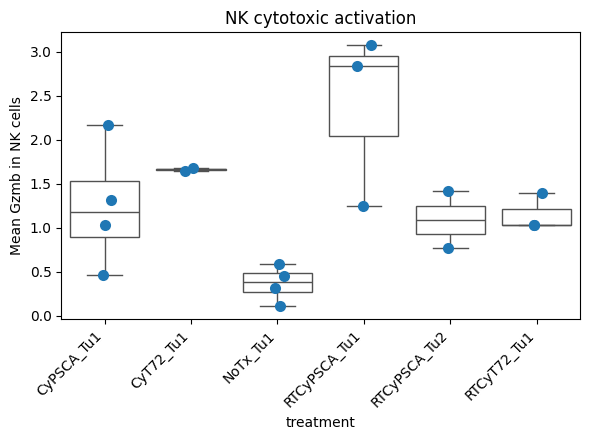

In [18]:
plot_df = nk_activation_summary.copy()

plt.figure(figsize=(6, 4.5))
sns.stripplot(
    data=plot_df,
    x="treatment",
    y="mean_Gzmb",
    size=8,
    jitter=True
)
sns.boxplot(
    data=plot_df,
    x="treatment",
    y="mean_Gzmb",
    showfliers=False,
    boxprops={"facecolor": "none"}
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Gzmb in NK cells")
plt.title("NK cytotoxic activation")
plt.tight_layout()
plt.show()

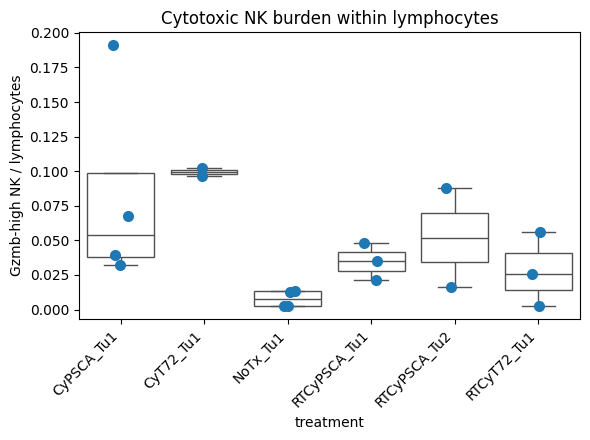

In [19]:
plot_df = nk_high_lymphocyte_summary.copy()

plt.figure(figsize=(6, 4.5))
sns.stripplot(
    data=plot_df,
    x="treatment",
    y="frac_NK_Gzmb_high_q75_of_lymphocytes",
    size=8,
    jitter=True
)
sns.boxplot(
    data=plot_df,
    x="treatment",
    y="frac_NK_Gzmb_high_q75_of_lymphocytes",
    showfliers=False,
    boxprops={"facecolor": "none"}
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Gzmb-high NK / lymphocytes")
plt.title("Cytotoxic NK burden within lymphocytes")
plt.tight_layout()
plt.show()

## NK Statistics

In [20]:
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

def cliffs_delta_b_vs_a(a, b):
    a = np.asarray(a)
    b = np.asarray(b)

    greater = 0
    less = 0

    for bi in b:
        greater += np.sum(bi > a)
        less += np.sum(bi < a)

    return (greater - less) / (len(a) * len(b))


def compare_metric(df, metric, group_a="CyPSCA_Tu1", group_b="RTCyPSCA_Tu1"):
    a = df.loc[df["treatment"].eq(group_a), metric].dropna()
    b = df.loc[df["treatment"].eq(group_b), metric].dropna()

    if len(a) >= 2 and len(b) >= 2:
        stat, p = mannwhitneyu(a, b, alternative="two-sided")
        delta = cliffs_delta_b_vs_a(a, b)
    else:
        p = np.nan
        delta = np.nan

    return {
        "metric": metric,
        "group_a": group_a,
        "group_b": group_b,
        "n_group_a": len(a),
        "n_group_b": len(b),
        "mean_group_a": a.mean(),
        "mean_group_b": b.mean(),
        "difference_b_minus_a": b.mean() - a.mean(),
        "cliffs_delta_b_vs_a": delta,
        "mannwhitney_p": p,
    }

In [21]:
nk_stat_rows = []

nk_stat_rows.append(
    compare_metric(nk_composition_summary, "frac_nk_of_lymphocytes")
)

nk_stat_rows.append(
    compare_metric(nk_composition_summary, "frac_cytotoxic_of_lymphocytes")
)

nk_stat_rows.append(
    compare_metric(nk_activation_summary, "mean_Gzmb")
)

nk_stat_rows.append(
    compare_metric(nk_activation_summary, "frac_NK_Gzmb_high_q75")
)

nk_stat_rows.append(
    compare_metric(nk_high_lymphocyte_summary, "frac_NK_Gzmb_high_q75_of_lymphocytes")
)

nk_stats_df = pd.DataFrame(nk_stat_rows)

display(nk_stats_df)

,metric,group_a,group_b,n_group_a,n_group_b,mean_group_a,mean_group_b,difference_b_minus_a,cliffs_delta_b_vs_a,mannwhitney_p
0,frac_nk_of_lymphocytes,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.180058,0.051301,-0.128757,-1.000000,0.057143
1,frac_cytotoxic_of_lymphocytes,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.577469,0.244180,-0.333289,-1.000000,0.057143
2,mean_Gzmb,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,1.245506,2.383913,1.138407,0.666667,0.228571
3,frac_NK_Gzmb_high_q75,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.422752,0.680995,0.258244,0.666667,0.228571
4,frac_NK_Gzmb_high_q75_of_lymphocytes,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.082610,0.034841,-0.047769,-0.500000,0.400000


# Cytotoxicity

In [22]:
nk_curated_pathway_panel = {
    "GranzymeDeath_GO": "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY",
    "NK_MediatedImmunity_GO": "GOBP_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY",
    "NK_Degranulation_GO": "GOBP_NATURAL_KILLER_CELL_DEGRANULATION",
    "LeukocyteCytotoxicity_GO": "GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY",
}

nk_panel_check = []

for short_name, gene_set_name in nk_curated_pathway_panel.items():
    nk_panel_check.append({
        "short_name": short_name,
        "gene_set_name": gene_set_name,
        "found": gene_set_name in all_gene_sets,
        "n_genes": len(all_gene_sets[gene_set_name]) if gene_set_name in all_gene_sets else np.nan,
        "source_file": gene_set_metadata.loc[
            gene_set_metadata["gene_set"].eq(gene_set_name),
            "source_file"
        ].iloc[0] if gene_set_name in all_gene_sets else np.nan
    })

nk_panel_check_df = pd.DataFrame(nk_panel_check)
display(nk_panel_check_df)

,short_name,gene_set_name,found,n_genes,source_file
0,GranzymeDeath_GO,GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_S...,True,11,m5.go.bp.v2026.1.Mm.symbols.gmt
1,NK_MediatedImmunity_GO,GOBP_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY,True,99,m5.go.bp.v2026.1.Mm.symbols.gmt
2,NK_Degranulation_GO,GOBP_NATURAL_KILLER_CELL_DEGRANULATION,True,11,m5.go.bp.v2026.1.Mm.symbols.gmt
3,LeukocyteCytotoxicity_GO,GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY,True,181,m5.go.bp.v2026.1.Mm.symbols.gmt


In [23]:
for short_name, gene_set_name in nk_curated_pathway_panel.items():
    genes = all_gene_sets[gene_set_name]
    genes_present = [g for g in genes if g in adata.var_names]
    genes_missing = [g for g in genes if g not in adata.var_names]

    print("\n" + short_name)
    print(gene_set_name)
    print(f"Total genes in pathway: {len(genes)}")
    print(f"Genes present in adata: {len(genes_present)}")
    print(f"Genes missing from adata: {len(genes_missing)}")
    print("Present genes:")
    print(genes_present)


GranzymeDeath_GO
GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY
Total genes in pathway: 11
Genes present in adata: 10
Genes missing from adata: 1
Present genes:
['Bnip3', 'Gzma', 'Gzmb', 'Gzmc', 'Gzmk', 'Lamp1', 'Nkg7', 'Prf1', 'Srgn', 'Ube4b']

NK_MediatedImmunity_GO
GOBP_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY
Total genes in pathway: 99
Genes present in adata: 98
Genes missing from adata: 1
Present genes:
['Ap1g1', 'Arl8b', 'Arrb2', 'Bid', 'Cadm1', 'Calhm6', 'Cd160', 'Cd2', 'Cd226', 'Cd96', 'Ceacam1', 'Cebpg', 'Clec12b', 'Clec2d', 'Clnk', 'Coro1a', 'Crk', 'Crtam', 'Dpp4', 'Fcgr4', 'Gfer', 'Gimap3', 'Gimap5', 'Grb2', 'Gzmb', 'Gzmc', 'H2-M3', 'H60b', 'H60c', 'Havcr2', 'Hcst', 'Igf2', 'Il12a', 'Il12b', 'Il18', 'Il18rap', 'Il21', 'Inpp5d', 'Kctd9', 'Kif5b', 'Klrb1', 'Klrb1a', 'Klrb1b', 'Klrb1c', 'Klrb1f', 'Klrc1', 'Klrc3', 'Klrd1', 'Klre1', 'Klri1', 'Klri2', 'Klrk1', 'Lag3', 'Lamp1', 'Lep', 'Lgals9', 'Lyst', 'Nectin2', 'Nectin4', 'Nfkbiz', 'Nkg7', 'Pik3c3', 'Pik3cb', 'Pik3

In [24]:
available_genes = set(adata.var_names.astype(str))

nk_score_records = []

for short_name, gene_set_name in nk_curated_pathway_panel.items():
    pathway_genes = all_gene_sets[gene_set_name]

    matched_genes = [g for g in pathway_genes if g in available_genes]
    missing_genes = [g for g in pathway_genes if g not in available_genes]

    score_col = f"{short_name}_score"

    print(f"\nScoring: {short_name}")
    print(f"  MSigDB pathway: {gene_set_name}")
    print(f"  pathway genes: {len(pathway_genes)}")
    print(f"  matched genes: {len(matched_genes)}")
    print(f"  missing genes: {len(missing_genes)}")

    if len(matched_genes) < 5:
        print(f"  WARNING: fewer than 5 matched genes. Skipping {short_name}.")
        continue

    sc.tl.score_genes(
        adata,
        gene_list=matched_genes,
        score_name=score_col,
        use_raw=False
    )

    nk_score_records.append({
        "short_name": short_name,
        "gene_set_name": gene_set_name,
        "score_col": score_col,
        "n_pathway_genes": len(pathway_genes),
        "n_matched_genes": len(matched_genes),
        "n_missing_genes": len(missing_genes),
        "matched_genes": ";".join(matched_genes),
        "missing_genes": ";".join(missing_genes),
    })

nk_score_summary_df = pd.DataFrame(nk_score_records)
display(nk_score_summary_df)

nk_score_summary_df.to_csv(
    outdir / "nk_curated_cytotoxic_pathway_score_gene_matching_summary.csv",
    index=False
)


Scoring: GranzymeDeath_GO
  MSigDB pathway: GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY
  pathway genes: 11
  matched genes: 10
  missing genes: 1

Scoring: NK_MediatedImmunity_GO
  MSigDB pathway: GOBP_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY
  pathway genes: 99
  matched genes: 98
  missing genes: 1

Scoring: NK_Degranulation_GO
  MSigDB pathway: GOBP_NATURAL_KILLER_CELL_DEGRANULATION
  pathway genes: 11
  matched genes: 11
  missing genes: 0

Scoring: LeukocyteCytotoxicity_GO
  MSigDB pathway: GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY
  pathway genes: 181
  matched genes: 167
  missing genes: 14


,short_name,gene_set_name,score_col,n_pathway_genes,n_matched_genes,n_missing_genes,matched_genes,missing_genes
0,GranzymeDeath_GO,GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_S...,GranzymeDeath_GO_score,11,10,1,Bnip3;Gzma;Gzmb;Gzmc;Gzmk;Lamp1;Nkg7;Prf1;Srgn...,Gsdme
1,NK_MediatedImmunity_GO,GOBP_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY,NK_MediatedImmunity_GO_score,99,98,1,Ap1g1;Arl8b;Arrb2;Bid;Cadm1;Calhm6;Cd160;Cd2;C...,Klrc2
2,NK_Degranulation_GO,GOBP_NATURAL_KILLER_CELL_DEGRANULATION,NK_Degranulation_GO_score,11,11,0,Ap1g1;Cd160;Coro1a;Fcgr4;Kctd9;Lamp1;Lgals9;Nk...,
3,LeukocyteCytotoxicity_GO,GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY,LeukocyteCytotoxicity_GO_score,181,167,14,Ager;Ap1g1;Arg1;Arl8b;Arrb2;Azgp1;B2m;Bid;Cadm...,2410137M14Rik;Cd1d2;Cx3cr1;Cyrib;Gfus;H2-Ea;H2...


In [25]:
nk_score_cols = nk_score_summary_df["score_col"].tolist()

nk_pathway_summary = (
    adata.obs
    .loc[
        adata.obs["c2l_permissive"].astype(str).eq("NK")
        & adata.obs["treatment"].isin([
            "CyPSCA_Tu1",
            "RTCyPSCA_Tu1",
            "RTCyPSCA_Tu2",
            "CyT72_Tu1",
            "RTCyT72_Tu1",
            "NoTx_Tu1",
        ])
    ]
    .groupby(["tissue", "condition", "tumor_loc", "replicate_num", "treatment"], observed=True)
    .agg(
        n_nk=("c2l_permissive", "size"),
        **{f"{score_col}_mean": (score_col, "mean") for score_col in nk_score_cols},
        **{f"{score_col}_median": (score_col, "median") for score_col in nk_score_cols}
    )
    .reset_index()
)

display(nk_pathway_summary)

nk_pathway_summary.to_csv(
    outdir / "nk_cell_curated_cytotoxic_pathway_summary.csv",
    index=False
)

,tissue,condition,tumor_loc,replicate_num,treatment,n_nk,GranzymeDeath_GO_score_mean,NK_MediatedImmunity_GO_score_mean,NK_Degranulation_GO_score_mean,LeukocyteCytotoxicity_GO_score_mean,GranzymeDeath_GO_score_median,NK_MediatedImmunity_GO_score_median,NK_Degranulation_GO_score_median,LeukocyteCytotoxicity_GO_score_median
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,2400,0.096387,0.003237,-0.013003,0.016388,0.018465,-0.005068,-0.060636,0.008900
1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,722,0.486589,0.095717,0.127618,0.097926,0.461853,0.090947,0.098934,0.092694
2,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1,247,0.855463,0.200917,0.263120,0.199760,0.875961,0.203352,0.262336,0.207758
3,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1,252,0.365547,0.052420,0.048471,0.073276,0.325047,0.046910,0.020903,0.065070
4,CyT72_1_2,CyT72,1,2,CyT72_Tu1,154,0.768966,0.122856,0.113677,0.106157,0.780043,0.118667,0.115595,0.104965
5,CyT72_1_4,CyT72,1,4,CyT72_Tu1,340,0.690439,0.130443,0.148991,0.129720,0.672527,0.132765,0.122568,0.131858
6,NoTx_1_1,NoTx,1,1,NoTx_Tu1,19,0.004671,0.010499,-0.076364,0.026886,0.004086,0.013325,-0.125734,0.030349
7,NoTx_1_2,NoTx,1,2,NoTx_Tu1,116,-0.168404,-0.058424,-0.106355,-0.051370,-0.206159,-0.056575,-0.147068,-0.057700
8,NoTx_1_3,NoTx,1,3,NoTx_Tu1,181,0.043975,-0.045496,-0.111936,-0.039780,-0.106316,-0.056922,-0.152339,-0.049822
9,NoTx_1_4,NoTx,1,4,NoTx_Tu1,342,-0.064046,-0.034070,-0.077570,-0.019857,-0.175969,-0.048102,-0.091587,-0.031103


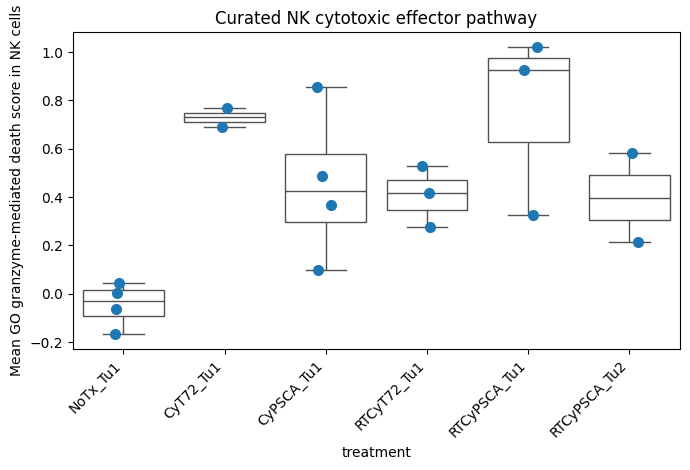

In [26]:
plot_order = [
    "NoTx_Tu1",
    "CyT72_Tu1",
    "CyPSCA_Tu1",
    "RTCyT72_Tu1",
    "RTCyPSCA_Tu1",
    "RTCyPSCA_Tu2",
]

metric = "GranzymeDeath_GO_score_mean"

plt.figure(figsize=(7, 4.8))

sns.stripplot(
    data=nk_pathway_summary,
    x="treatment",
    y=metric,
    order=plot_order,
    size=8,
    jitter=True
)

sns.boxplot(
    data=nk_pathway_summary,
    x="treatment",
    y=metric,
    order=plot_order,
    showfliers=False,
    boxprops={"facecolor": "none"}
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean GO granzyme-mediated death score in NK cells")
plt.title("Curated NK cytotoxic effector pathway")
plt.tight_layout()
plt.show()

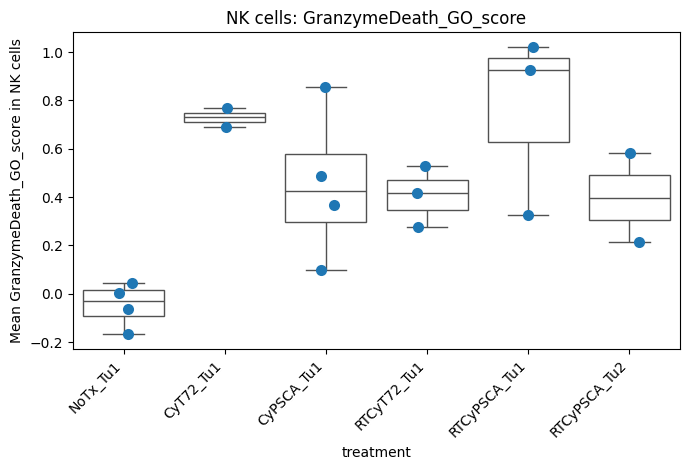

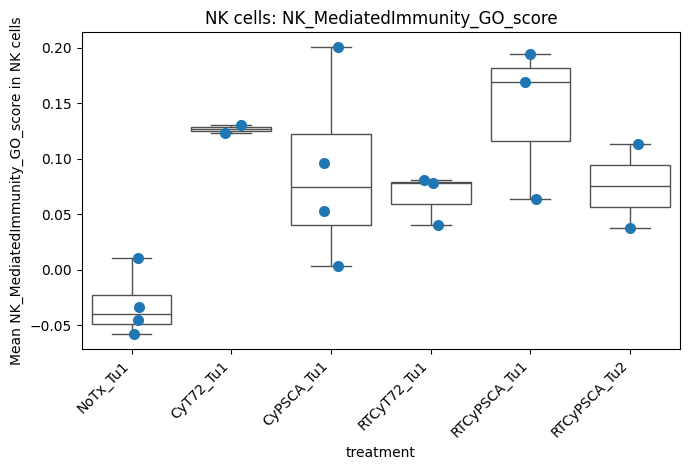

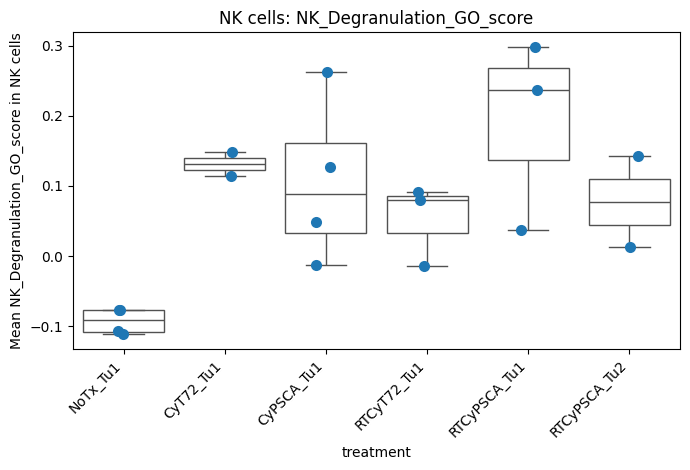

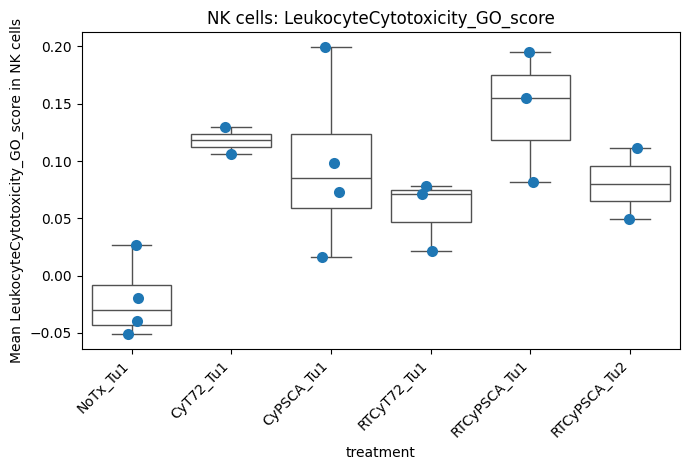

In [27]:
for score_col in nk_score_cols:
    metric = f"{score_col}_mean"

    plt.figure(figsize=(7, 4.8))

    sns.stripplot(
        data=nk_pathway_summary,
        x="treatment",
        y=metric,
        order=plot_order,
        size=8,
        jitter=True
    )

    sns.boxplot(
        data=nk_pathway_summary,
        x="treatment",
        y=metric,
        order=plot_order,
        showfliers=False,
        boxprops={"facecolor": "none"}
    )

    plt.xticks(rotation=45, ha="right")
    plt.ylabel(f"Mean {score_col} in NK cells")
    plt.title(f"NK cells: {score_col}")
    plt.tight_layout()
    plt.show()

## NK cyt high look

In [28]:
nk_score_cols = [
    "GranzymeDeath_GO_score",
    "NK_MediatedImmunity_GO_score",
    "NK_Degranulation_GO_score",
    "LeukocyteCytotoxicity_GO_score",
]

nk_score_cols = [c for c in nk_score_cols if c in adata.obs.columns]

nk_mask = adata.obs["c2l_permissive"].astype(str).eq("NK")

for score_col in nk_score_cols:
    q75 = adata.obs.loc[nk_mask, score_col].quantile(0.75)
    q90 = adata.obs.loc[nk_mask, score_col].quantile(0.90)

    adata.obs[f"{score_col}_NK_q75_high"] = nk_mask & (adata.obs[score_col] >= q75)
    adata.obs[f"{score_col}_NK_q90_high"] = nk_mask & (adata.obs[score_col] >= q90)

    print(score_col)
    print(f"  NK-specific q75: {q75:.4f}")
    print(f"  NK-specific q90: {q90:.4f}")

GranzymeDeath_GO_score
  NK-specific q75: 0.5680
  NK-specific q90: 1.0175
NK_MediatedImmunity_GO_score
  NK-specific q75: 0.1034
  NK-specific q90: 0.2058
NK_Degranulation_GO_score
  NK-specific q75: 0.1567
  NK-specific q90: 0.3715
LeukocyteCytotoxicity_GO_score
  NK-specific q75: 0.1049
  NK-specific q90: 0.1964


In [29]:
nk_q75_summary = (
    adata.obs
    .loc[
        adata.obs["c2l_permissive"].astype(str).eq("NK")
        & adata.obs["treatment"].isin([
            "NoTx_Tu1",
            "CyT72_Tu1",
            "CyPSCA_Tu1",
            "RTCyT72_Tu1",
            "RTCyPSCA_Tu1",
            "RTCyPSCA_Tu2",
        ])
    ]
    .groupby(["tissue", "condition", "tumor_loc", "replicate_num", "treatment"], observed=True)
    .agg(
        n_nk=("c2l_permissive", "size"),
        **{
            f"{score_col}_NK_q75_frac": (f"{score_col}_NK_q75_high", "mean")
            for score_col in nk_score_cols
        },
        **{
            f"{score_col}_NK_q90_frac": (f"{score_col}_NK_q90_high", "mean")
            for score_col in nk_score_cols
        }
    )
    .reset_index()
)

display(nk_q75_summary)

,tissue,condition,tumor_loc,replicate_num,treatment,n_nk,GranzymeDeath_GO_score_NK_q75_frac,NK_MediatedImmunity_GO_score_NK_q75_frac,NK_Degranulation_GO_score_NK_q75_frac,LeukocyteCytotoxicity_GO_score_NK_q75_frac,GranzymeDeath_GO_score_NK_q90_frac,NK_MediatedImmunity_GO_score_NK_q90_frac,NK_Degranulation_GO_score_NK_q90_frac,LeukocyteCytotoxicity_GO_score_NK_q90_frac
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,2400,0.121250,0.090417,0.186667,0.074167,0.021667,0.010417,0.055833,0.007083
1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,722,0.425208,0.447368,0.405817,0.463989,0.152355,0.148199,0.174515,0.139889
2,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1,247,0.789474,0.846154,0.643725,0.878543,0.368421,0.485830,0.323887,0.550607
3,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1,252,0.281746,0.238095,0.289683,0.309524,0.071429,0.039683,0.087302,0.055556
4,CyT72_1_2,CyT72,1,2,CyT72_Tu1,154,0.610390,0.571429,0.415584,0.500000,0.344156,0.233766,0.175325,0.123377
5,CyT72_1_4,CyT72,1,4,CyT72_Tu1,340,0.611765,0.605882,0.441176,0.605882,0.276471,0.211765,0.226471,0.205882
6,NoTx_1_1,NoTx,1,1,NoTx_Tu1,19,0.052632,0.052632,0.157895,0.000000,0.000000,0.000000,0.000000,0.000000
7,NoTx_1_2,NoTx,1,2,NoTx_Tu1,116,0.017241,0.000000,0.051724,0.000000,0.000000,0.000000,0.000000,0.000000
8,NoTx_1_3,NoTx,1,3,NoTx_Tu1,181,0.160221,0.033149,0.082873,0.022099,0.033149,0.005525,0.011050,0.000000
9,NoTx_1_4,NoTx,1,4,NoTx_Tu1,342,0.084795,0.052632,0.090643,0.026316,0.029240,0.008772,0.014620,0.002924


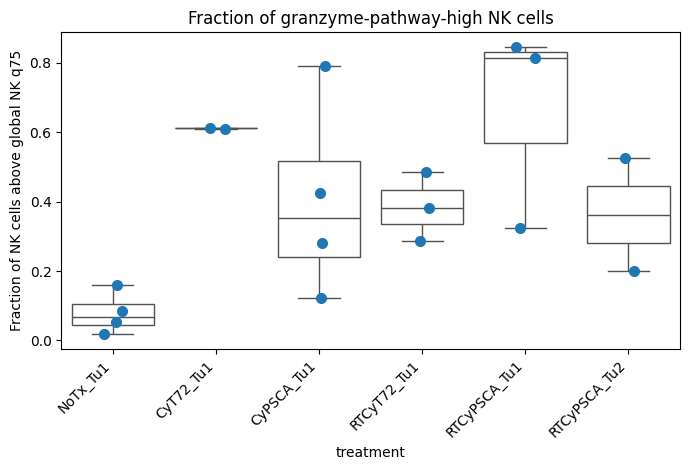

In [30]:
plot_order = [
    "NoTx_Tu1",
    "CyT72_Tu1",
    "CyPSCA_Tu1",
    "RTCyT72_Tu1",
    "RTCyPSCA_Tu1",
    "RTCyPSCA_Tu2",
]

metric = "GranzymeDeath_GO_score_NK_q75_frac"

plt.figure(figsize=(7, 4.8))

sns.stripplot(
    data=nk_q75_summary,
    x="treatment",
    y=metric,
    order=plot_order,
    size=8,
    jitter=True
)

sns.boxplot(
    data=nk_q75_summary,
    x="treatment",
    y=metric,
    order=plot_order,
    showfliers=False,
    boxprops={"facecolor": "none"}
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Fraction of NK cells above global NK q75")
plt.title("Fraction of granzyme-pathway-high NK cells")
plt.tight_layout()
plt.show()

## NK stats

In [31]:
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

def cliffs_delta_b_vs_a(a, b):
    """
    Positive value means group_b tends to be higher than group_a.
    """
    a = np.asarray(a)
    b = np.asarray(b)

    greater = 0
    less = 0

    for bi in b:
        greater += np.sum(bi > a)
        less += np.sum(bi < a)

    return (greater - less) / (len(a) * len(b))


def permutation_test_mean_diff(a, b, n_perm=10000, alternative="greater", seed=0):
    """
    Tests whether mean(b) - mean(a) is larger than expected by chance.
    alternative='greater' means group_b > group_a.
    """
    rng = np.random.default_rng(seed)

    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    observed = np.mean(b) - np.mean(a)
    pooled = np.concatenate([a, b])
    n_a = len(a)

    perm_diffs = np.empty(n_perm)

    for i in range(n_perm):
        shuffled = rng.permutation(pooled)
        perm_a = shuffled[:n_a]
        perm_b = shuffled[n_a:]
        perm_diffs[i] = np.mean(perm_b) - np.mean(perm_a)

    if alternative == "greater":
        p = np.mean(perm_diffs >= observed)
    elif alternative == "less":
        p = np.mean(perm_diffs <= observed)
    else:
        p = np.mean(np.abs(perm_diffs) >= abs(observed))

    return observed, p

In [32]:
nk_score_metrics = [
    "GranzymeDeath_GO_score_mean",
    "NK_MediatedImmunity_GO_score_mean",
    "NK_Degranulation_GO_score_mean",
    "LeukocyteCytotoxicity_GO_score_mean",
]

nk_score_metrics = [m for m in nk_score_metrics if m in nk_pathway_summary.columns]

group_a = "CyPSCA_Tu1"
group_b = "RTCyPSCA_Tu1"

nk_stats_rows = []

for metric in nk_score_metrics:
    a = nk_pathway_summary.loc[
        nk_pathway_summary["treatment"].eq(group_a),
        metric
    ].dropna()

    b = nk_pathway_summary.loc[
        nk_pathway_summary["treatment"].eq(group_b),
        metric
    ].dropna()

    # one-sided: RTCyPSCA_Tu1 > CyPSCA_Tu1
    if len(a) >= 2 and len(b) >= 2:
        mw_stat, mw_p_one_sided = mannwhitneyu(
            a,
            b,
            alternative="less"  # tests whether a < b
        )

        mw_stat_two, mw_p_two_sided = mannwhitneyu(
            a,
            b,
            alternative="two-sided"
        )

        mean_diff, perm_p_one_sided = permutation_test_mean_diff(
            a,
            b,
            n_perm=10000,
            alternative="greater",
            seed=42
        )

        delta = cliffs_delta_b_vs_a(a, b)

    else:
        mw_p_one_sided = np.nan
        mw_p_two_sided = np.nan
        perm_p_one_sided = np.nan
        mean_diff = np.nan
        delta = np.nan

    nk_stats_rows.append({
        "metric": metric,
        "group_a": group_a,
        "group_b": group_b,
        "n_group_a": len(a),
        "n_group_b": len(b),
        "mean_group_a": a.mean(),
        "mean_group_b": b.mean(),
        "median_group_a": a.median(),
        "median_group_b": b.median(),
        "mean_difference_b_minus_a": b.mean() - a.mean(),
        "median_difference_b_minus_a": b.median() - a.median(),
        "cliffs_delta_b_vs_a": delta,
        "mannwhitney_p_one_sided_b_greater": mw_p_one_sided,
        "mannwhitney_p_two_sided": mw_p_two_sided,
        "permutation_p_one_sided_b_greater": perm_p_one_sided,
    })

nk_pathway_stats_df = pd.DataFrame(nk_stats_rows)

display(nk_pathway_stats_df)

nk_pathway_stats_df.to_csv(
    outdir / "NK_curated_pathway_stats_CyPSCA_Tu1_vs_RTCyPSCA_Tu1.csv",
    index=False
)

,metric,group_a,group_b,n_group_a,n_group_b,mean_group_a,mean_group_b,median_group_a,median_group_b,mean_difference_b_minus_a,median_difference_b_minus_a,cliffs_delta_b_vs_a,mannwhitney_p_one_sided_b_greater,mannwhitney_p_two_sided,permutation_p_one_sided_b_greater
0,GranzymeDeath_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.450997,0.758970,0.426068,0.926980,0.307973,0.500912,0.500000,0.200000,0.400000,0.1477
1,NK_MediatedImmunity_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.088073,0.142290,0.074068,0.168691,0.054217,0.094623,0.333333,0.314286,0.628571,0.2331
2,NK_Degranulation_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.106552,0.190795,0.088045,0.236524,0.084244,0.148479,0.333333,0.314286,0.628571,0.2226
3,LeukocyteCytotoxicity_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.096837,0.143985,0.085601,0.155276,0.047148,0.069675,0.333333,0.314286,0.628571,0.2331


In [33]:
from statsmodels.stats.multitest import multipletests

nk_pathway_stats_df["fdr_mannwhitney_one_sided"] = multipletests(
    nk_pathway_stats_df["mannwhitney_p_one_sided_b_greater"].fillna(1.0),
    method="fdr_bh"
)[1]

nk_pathway_stats_df["fdr_permutation_one_sided"] = multipletests(
    nk_pathway_stats_df["permutation_p_one_sided_b_greater"].fillna(1.0),
    method="fdr_bh"
)[1]

display(
    nk_pathway_stats_df.sort_values("permutation_p_one_sided_b_greater")
)

,metric,group_a,group_b,n_group_a,n_group_b,mean_group_a,mean_group_b,median_group_a,median_group_b,mean_difference_b_minus_a,median_difference_b_minus_a,cliffs_delta_b_vs_a,mannwhitney_p_one_sided_b_greater,mannwhitney_p_two_sided,permutation_p_one_sided_b_greater,fdr_mannwhitney_one_sided,fdr_permutation_one_sided
0,GranzymeDeath_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.450997,0.758970,0.426068,0.926980,0.307973,0.500912,0.500000,0.200000,0.400000,0.1477,0.314286,0.2331
2,NK_Degranulation_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.106552,0.190795,0.088045,0.236524,0.084244,0.148479,0.333333,0.314286,0.628571,0.2226,0.314286,0.2331
1,NK_MediatedImmunity_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.088073,0.142290,0.074068,0.168691,0.054217,0.094623,0.333333,0.314286,0.628571,0.2331,0.314286,0.2331
3,LeukocyteCytotoxicity_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.096837,0.143985,0.085601,0.155276,0.047148,0.069675,0.333333,0.314286,0.628571,0.2331,0.314286,0.2331


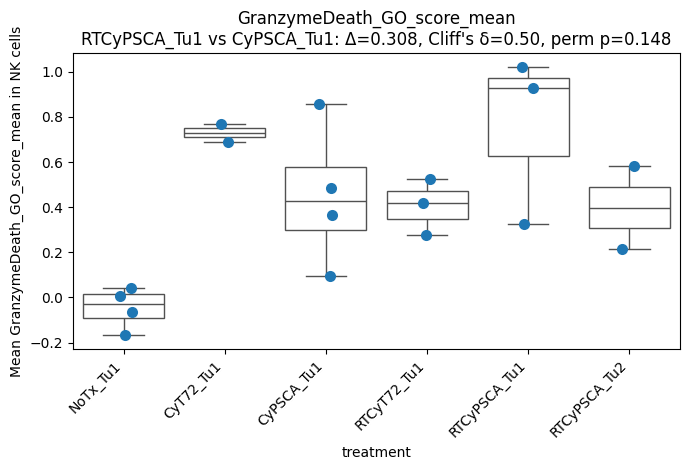

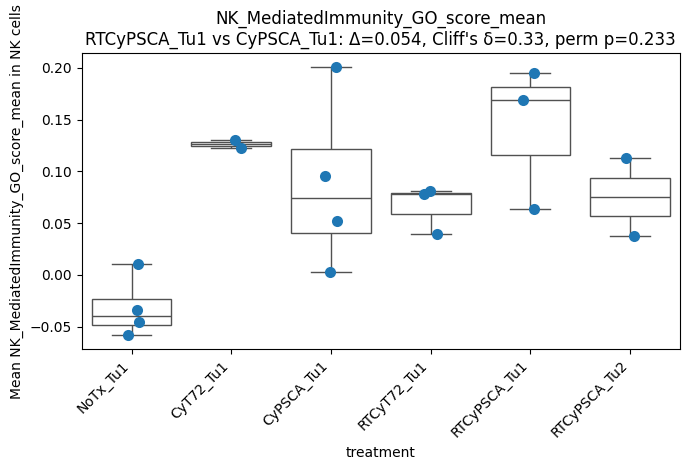

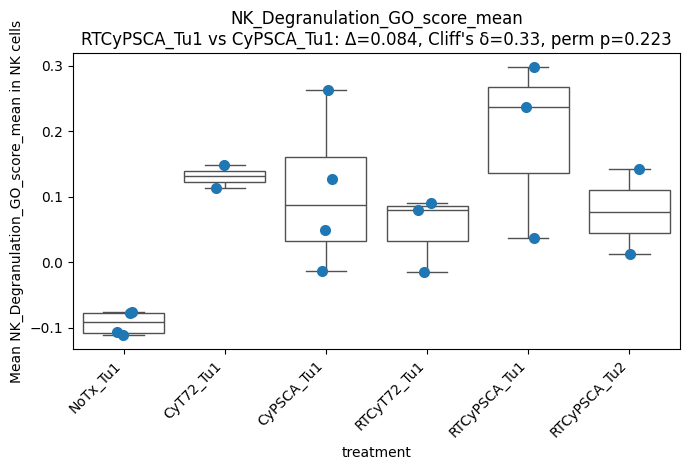

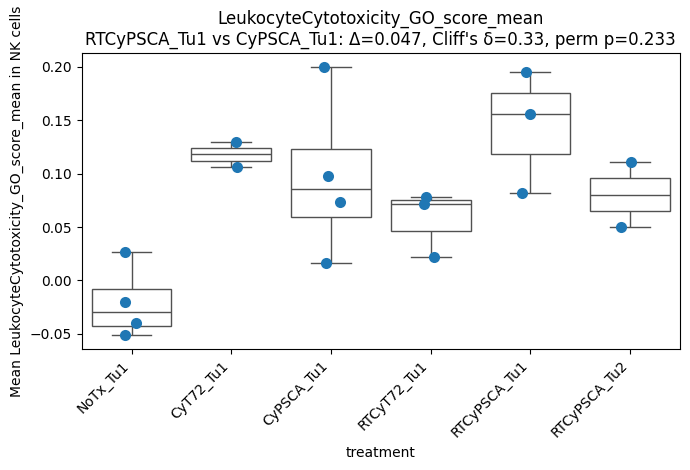

In [34]:
plot_order = [
    "NoTx_Tu1",
    "CyT72_Tu1",
    "CyPSCA_Tu1",
    "RTCyT72_Tu1",
    "RTCyPSCA_Tu1",
    "RTCyPSCA_Tu2",
]

for metric in nk_score_metrics:
    stat_row = nk_pathway_stats_df.loc[
        nk_pathway_stats_df["metric"].eq(metric)
    ].iloc[0]

    p_perm = stat_row["permutation_p_one_sided_b_greater"]
    delta = stat_row["cliffs_delta_b_vs_a"]
    diff = stat_row["mean_difference_b_minus_a"]

    plt.figure(figsize=(7, 4.8))

    sns.stripplot(
        data=nk_pathway_summary,
        x="treatment",
        y=metric,
        order=plot_order,
        size=8,
        jitter=True
    )

    sns.boxplot(
        data=nk_pathway_summary,
        x="treatment",
        y=metric,
        order=plot_order,
        showfliers=False,
        boxprops={"facecolor": "none"}
    )

    plt.xticks(rotation=45, ha="right")
    plt.ylabel(f"Mean {metric} in NK cells")
    plt.title(
        f"{metric}\n"
        f"RTCyPSCA_Tu1 vs CyPSCA_Tu1: Δ={diff:.3f}, Cliff's δ={delta:.2f}, perm p={p_perm:.3f}"
    )
    plt.tight_layout()
    plt.show()

In [35]:
nk_q75_metrics = [
    "GranzymeDeath_GO_score_NK_q75_frac",
    "NK_MediatedImmunity_GO_score_NK_q75_frac",
    "NK_Degranulation_GO_score_NK_q75_frac",
    "LeukocyteCytotoxicity_GO_score_NK_q75_frac",
]

nk_q75_metrics = [m for m in nk_q75_metrics if m in nk_q75_summary.columns]

nk_q75_stats_rows = []

for metric in nk_q75_metrics:
    a = nk_q75_summary.loc[
        nk_q75_summary["treatment"].eq(group_a),
        metric
    ].dropna()

    b = nk_q75_summary.loc[
        nk_q75_summary["treatment"].eq(group_b),
        metric
    ].dropna()

    if len(a) >= 2 and len(b) >= 2:
        mw_stat, mw_p_one_sided = mannwhitneyu(
            a,
            b,
            alternative="less"
        )

        mw_stat_two, mw_p_two_sided = mannwhitneyu(
            a,
            b,
            alternative="two-sided"
        )

        mean_diff, perm_p_one_sided = permutation_test_mean_diff(
            a,
            b,
            n_perm=10000,
            alternative="greater",
            seed=42
        )

        delta = cliffs_delta_b_vs_a(a, b)

    else:
        mw_p_one_sided = np.nan
        mw_p_two_sided = np.nan
        perm_p_one_sided = np.nan
        mean_diff = np.nan
        delta = np.nan

    nk_q75_stats_rows.append({
        "metric": metric,
        "group_a": group_a,
        "group_b": group_b,
        "n_group_a": len(a),
        "n_group_b": len(b),
        "mean_group_a": a.mean(),
        "mean_group_b": b.mean(),
        "mean_difference_b_minus_a": b.mean() - a.mean(),
        "cliffs_delta_b_vs_a": delta,
        "mannwhitney_p_one_sided_b_greater": mw_p_one_sided,
        "mannwhitney_p_two_sided": mw_p_two_sided,
        "permutation_p_one_sided_b_greater": perm_p_one_sided,
    })

nk_q75_stats_df = pd.DataFrame(nk_q75_stats_rows)

display(nk_q75_stats_df)

nk_q75_stats_df.to_csv(
    outdir / "NK_curated_pathway_q75_fraction_stats_CyPSCA_Tu1_vs_RTCyPSCA_Tu1.csv",
    index=False
)

,metric,group_a,group_b,n_group_a,n_group_b,mean_group_a,mean_group_b,mean_difference_b_minus_a,cliffs_delta_b_vs_a,mannwhitney_p_one_sided_b_greater,mannwhitney_p_two_sided,permutation_p_one_sided_b_greater
0,GranzymeDeath_GO_score_NK_q75_frac,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.404419,0.661136,0.256717,0.666667,0.114286,0.228571,0.1409
1,NK_MediatedImmunity_GO_score_NK_q75_frac,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.405509,0.638763,0.233255,0.500000,0.200000,0.400000,0.2000
2,NK_Degranulation_GO_score_NK_q75_frac,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.381473,0.533183,0.151710,0.500000,0.200000,0.400000,0.2051
3,LeukocyteCytotoxicity_GO_score_NK_q75_frac,CyPSCA_Tu1,RTCyPSCA_Tu1,4,3,0.431555,0.641277,0.209722,0.333333,0.314286,0.628571,0.2331
